# Pipeline — Analyse et Modélisation du Risque d'Insécurité Alimentaire des Ménages au Bénin

**Mémoire — Master Statistique Appliquée au Vivant (CIPMA / Chaire UNESCO)**
Auteur : DAHOUI Pinel Baudelaire T. — Directeur : Dr. Nicodème ATCHADE

Ce notebook implémente le pipeline décrit dans la section *Matériel et Méthodologie* :

1. Chargement de l'enquête **AGVSAN Bénin 2017** (14 952 ménages, 1406 variables)
2. Construction de la **variable dépendante** `Y` (3 définitions : référence, stricte, élargie)
3. Variables indépendantes selon les **5 capitaux SLF** + **reconstruction indépendante du SCA**
   depuis les 18 items bruts et **Kappa de concordance** avec la classification officielle (§4.2.3-4.2.4)
4. Nettoyage & **manquants informatifs** (agriculture, chocs, cheptel)
5. Analyse descriptive **§4.4.2–4.4.4** (univariée focale, normalité, bivariée) +
   tests pré-estimation (χ², Mann-Whitney, VIF, **Box-Tidwell**, correction FDR)
6. Partition stratifiée 70/30 + déséquilibre de classes (**class weighting**, SMOTE comparé en §9)
7. **Modèle 1 : Régression Logistique** — Elastic-Net **pondérée par les poids d'enquête** ;
   Odds Ratios avec **erreurs-types robustes en grappes** (pseudo-vraisemblance pondérée)
8. **Modèle 2 : Random Forest** — `sample_weight` = poids d'enquête (§4.5.4)
9. **Modèle 3 : XGBoost** — poids d'enquête × `scale_pos_weight` (§4.5.5) + comparaison **SMOTE**
10. **Validation croisée par grappes** (`GroupKFold`, K=10)
11. Évaluation & comparaison (AUROC + IC 95 % + **DeLong**, Recall, F1, Brier)
    + **analyse de sensibilité des 3 définitions de Y** (§4.2.4)
12. Calibration (courbes, Hosmer-Lemeshow, recalibration isotonique)
13. **Interprétabilité SHAP**
14. **Cartographie prédictive** (agrégation communale pondérée, indice de Moran, Jenks, folium)

> ⚙️ Par défaut : **K=10 plis** et grilles d'hyperparamètres du mémoire (random search, §4.5.5).
> Poser la variable d'environnement `FAST_MODE=1` pour un test rapide (grilles réduites, K=5).

## 0. Configuration & imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import re
import unicodedata
import numpy as np
import pandas as pd

import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.multitest import multipletests

from sklearn.model_selection import train_test_split, GroupKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, f1_score, recall_score,
                             precision_score, brier_score_loss, confusion_matrix,
                             accuracy_score)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

import xgboost as xgb

import matplotlib.pyplot as plt
import seaborn as sns

# ---- Paramètres globaux (reproductibilité) ----
RANDOM_STATE = 42
# False (défaut) => K=10 plis + grilles du mémoire (random search, cf. §4.5.5).
# Surchargable par la variable d'environnement FAST_MODE=1 pour un test rapide.
FAST_MODE = os.environ.get("FAST_MODE", "0") == "1"
np.random.seed(RANDOM_STATE)

DATA_FILE = "AGVSA_BENIN_2017_MENAGE_RawData.dta"
GEO_FILE  = "benin_communes_ADM2.geojson"
OUT_DIR   = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

print("FAST_MODE =", FAST_MODE, "| RANDOM_STATE =", RANDOM_STATE)

FAST_MODE = False | RANDOM_STATE = 42


In [2]:
# Helper : corriger le mojibake des labels (fichier UTF-8 lu en latin1)
def fix_moji(s):
    if not isinstance(s, str):
        return s
    try:
        return s.encode("latin1").decode("utf-8")
    except Exception:
        return s

# Helper : normaliser un nom (accents, casse, ponctuation) pour les jointures
def norm_name(s):
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode()
    s = re.sub(r"[^a-z0-9]+", " ", s.lower()).strip()
    return s

## 1. Chargement de l'enquête AGVSAN 2017

Le fichier `.dta` est encodé en UTF-8 mais certains labels (tronqués à 80 caractères par
Stata) cassent le décodage UTF-8 ; on lit donc en **latin1** puis on corrige le mojibake
pour l'affichage. Le recodage des variables se fait par **codes numériques** (insensible au
mojibake).

In [3]:
import pyreadstat

# On lit d'abord les métadonnées seules (rapide) pour disposer du dictionnaire
_, META = pyreadstat.read_dta(DATA_FILE, metadataonly=True, encoding="latin1")
VALUE_LABELS = META.variable_value_labels
VAR_LABELS   = {k: fix_moji(v) for k, v in META.column_names_to_labels.items()}

print(f"Base AGVSAN 2017 : {META.number_rows} lignes × {META.number_columns} colonnes")
print("Variable dépendante trouvée :", "Round_INDICE_SECAL" in META.column_names)

Base AGVSAN 2017 : 14952 lignes × 1406 colonnes
Variable dépendante trouvée : True


In [4]:
# Liste ciblée des colonnes à charger (on évite de charger les 1406 colonnes)
COLS = [
    # --- identifiants / plan de sondage / géographie ---
    "Round_INDICE_SECAL", "weight_agvsa", "grappe", "menage",
    "departement", "commune", "Milieu2",
    # --- capital humain ---
    "Q_1_01", "Q_1_02", "Q_1_04", "Q_1_09", "Q_1_08_tcalculate",
    "Q_1_08_1", "Q_1_08_2", "Q_1_08_3", "Q_1_08_4", "Q_1_08_5",
    "Q_1_08_6", "Q_1_08_7", "Q_1_08_8", "Q_1_08_9", "Q_1_08_10",
    "Q_1_10_1", "Q_1_10_2",
    # --- capital physique / habitat ---
    "Q_3_02", "Q_3_03", "Q_3_04", "Q_3_06", "Q_3_10", "Q_3_11", "Q_3_12", "Q_3_13",
    # --- capital financier ---
    "Q_5_01", "Q_5_02_1", "Q_5_02_2", "Q_5_02_3",
    "Q_5_03_1_1", "Q_5_03_2_1", "Q_5_03_3_1", "Q_5_04_1",
    "Q_6_02", "Q_2_04",
    # --- capital naturel / agricole ---
    "Q_7_01", "Q_7_03_1", "Q_7_04", "Q_7_05", "Q_7_06",
    "Q_7_11_1_1",                                        # semences améliorées (Table 10)
    "Q_7_08_1_6_b1", "Q_7_08_1_7_b1", "Q_7_08_1_8_b1", "Q_7_08_1_9_b1",  # mois production propre
    "Q_8_01", "Q_8_02_01", "Q_8_02_02", "Q_8_02_03", "Q_8_02_04",
    "Q_8_02_05", "Q_8_02_06", "Q_8_02_07", "Q_8_02_08",
    # --- capital social / chocs / assistance ---
    "Q_9_01", "Q_9_02_01_a1", "Q_9_02_01_d1",
    "Q_9_03_01", "Q_9_03_02", "Q_9_03_03", "Q_9_03_04",
    "Q_9_03_05", "Q_9_03_06", "Q_9_03_07",
    "Q_9_04_02_1", "Q_9_04_03_1", "Q_10_1",
]

# Dépenses alimentaires (30 j) : toutes les colonnes Q_6_08_1_* (cash) et Q_6_08_2_* (crédit)
FOOD_EXP_COLS = [c for c in META.column_names if re.match(r"^Q_6_08_[12]_", c)]
COLS += FOOD_EXP_COLS

# Items de consommation alimentaire sur 7 jours (Section 4.01) : Q_4_01_{1..18}_a
# -> reconstruction indépendante du SCA (validation croisée de la classification officielle, §4.2.3)
FCS_ITEM_COLS = [f"Q_4_01_{i}_a" for i in range(1, 19) if f"Q_4_01_{i}_a" in META.column_names]
COLS += FCS_ITEM_COLS

COLS = [c for c in dict.fromkeys(COLS) if c in META.column_names]  # dédoublonne + garde existants
df_raw, _ = pyreadstat.read_dta(DATA_FILE, usecols=COLS, encoding="latin1")

# Certaines colonnes numériques peuvent être lues en 'object' -> coercition en numérique.
# On ne convertit pas 'commune'/'departement' (déjà int, servent d'identifiants).
_num_source = [c for c in COLS if c not in ("commune", "departement")]
for _c in _num_source:
    df_raw[_c] = pd.to_numeric(df_raw[_c], errors="coerce")

print("Colonnes chargées :", df_raw.shape[1], "| dépenses alim. :", len(FOOD_EXP_COLS), "items")
df_raw.head(3)

Colonnes chargées : 122 | dépenses alim. : 30 items


,departement,commune,grappe,menage,Q_1_01,Q_1_02,Q_1_04,Q_1_08_1,Q_1_08_2,Q_1_08_3,...,Q_9_03_04,Q_9_03_05,Q_9_03_06,Q_9_03_07,Q_9_04_02_1,Q_9_04_03_1,Q_10_1,weight_agvsa,Milieu2,Round_INDICE_SECAL
0,1,11,1,1,1,45,2,2,2,1,...,0,0,0,0,0,0,0,85.553021,2,2
1,1,11,1,2,1,50,2,1,3,2,...,0,6,0,3,0,0,0,85.553021,2,1
2,1,11,1,3,1,42,2,2,1,2,...,0,0,0,0,0,0,0,85.553021,2,1


## 2. Construction de la variable dépendante `Y`

`Round_INDICE_SECAL` (classification officielle CARI du PAM) :

| Code | Modalité | Statut |
|------|----------|--------|
| 1 | Sécurité alimentaire | `Y = 0` |
| 2 | Sécurité alimentaire limite | `Y = 0` |
| 3 | Insécurité alimentaire modérée | `Y = 1` |
| 4 | Insécurité alimentaire sévère | `Y = 1` |

**Définition de référence** : `Y = 1` si code ∈ {3, 4}. Deux définitions alternatives
(seuil strict {4} ; seuil élargi {2,3,4}) sont préparées pour l'analyse de sensibilité.

In [5]:
sec = df_raw["Round_INDICE_SECAL"]

df_raw["Y"]        = sec.isin([3, 4]).astype(float)      # référence
df_raw["Y_strict"] = sec.isin([4]).astype(float)         # seuil strict
df_raw["Y_large"]  = sec.isin([2, 3, 4]).astype(float)   # seuil élargi
for col in ["Y", "Y_strict", "Y_large"]:
    df_raw.loc[sec.isna(), col] = np.nan

n_na_y = int(sec.isna().sum())
print("Répartition Round_INDICE_SECAL :")
print(sec.value_counts(dropna=False).sort_index().to_string())
print(f"\nMénages exclus (Y manquant) : {n_na_y}")
print(f"\nPrévalence Y=1 (réf. {{3,4}})   : {df_raw['Y'].mean()*100:5.2f} %")
print(f"Prévalence Y=1 (strict {{4}})    : {df_raw['Y_strict'].mean()*100:5.2f} %")
print(f"Prévalence Y=1 (élargi {{2,3,4}}): {df_raw['Y_large'].mean()*100:5.2f} %")

Répartition Round_INDICE_SECAL :
Round_INDICE_SECAL
1    6998
2    6452
3    1378
4     124

Ménages exclus (Y manquant) : 0

Prévalence Y=1 (réf. {3,4})   : 10.05 %
Prévalence Y=1 (strict {4})    :  0.83 %
Prévalence Y=1 (élargi {2,3,4}): 53.20 %


In [6]:
# Prévalence pondérée (poids d'enquête) — nationale et par milieu de résidence
def weighted_mean(x, w):
    m = x.notna() & w.notna()
    return np.average(x[m], weights=w[m])

w = df_raw["weight_agvsa"]
milieu_map = {0: "Cotonou", 1: "Autre urbain", 2: "Rural"}
print("Prévalence Y=1 pondérée (nationale) : "
      f"{weighted_mean(df_raw['Y'], w)*100:5.2f} %\n")
print("Par milieu de résidence :")
for code, lab in milieu_map.items():
    sub = df_raw["Milieu2"] == code
    print(f"  {lab:14} : {weighted_mean(df_raw.loc[sub,'Y'], w[sub])*100:5.2f} % "
          f"(n={int(sub.sum())})")

# Milieu urbain agrégé vs rural (pour comparaison avec le mémoire)
urb = df_raw["Milieu2"].isin([0, 1])
rur = df_raw["Milieu2"] == 2
print(f"\n  Urbain (Cotonou+Autre) : {weighted_mean(df_raw.loc[urb,'Y'], w[urb])*100:5.2f} %")
print(f"  Rural                  : {weighted_mean(df_raw.loc[rur,'Y'], w[rur])*100:5.2f} %")

Prévalence Y=1 pondérée (nationale) :  9.66 %

Par milieu de résidence :
  Cotonou        :  1.52 % (n=1118)
  Autre urbain   :  7.26 % (n=5738)
  Rural          : 13.03 % (n=8096)

  Urbain (Cotonou+Autre) :  6.19 %
  Rural                  : 13.03 %


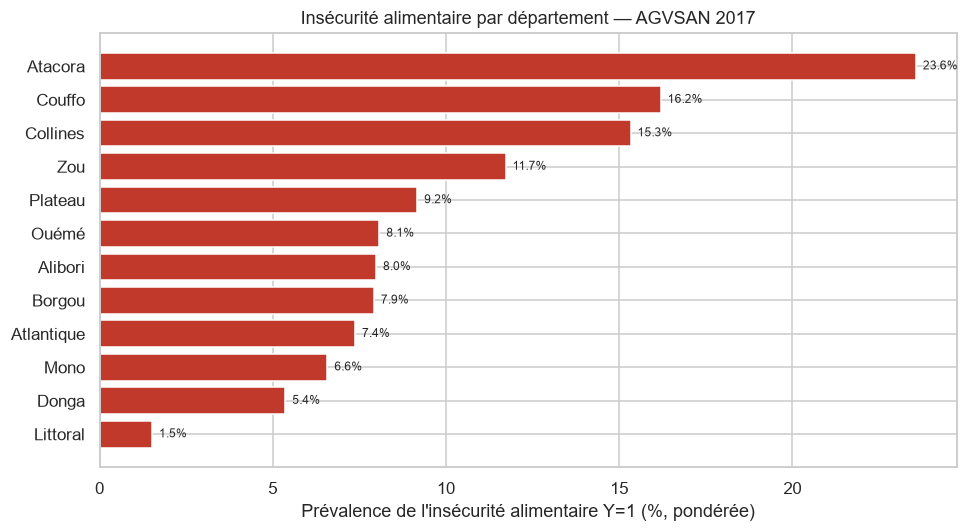

In [7]:
# Graphique : prévalence par département (pondérée)
dep_labels = {k: fix_moji(v) for k, v in VALUE_LABELS["departement"].items()}
rows = []
for code, lab in dep_labels.items():
    sub = df_raw["departement"] == code
    if sub.sum() > 0:
        rows.append((lab, weighted_mean(df_raw.loc[sub, "Y"], w[sub]) * 100, int(sub.sum())))
dep_prev = pd.DataFrame(rows, columns=["departement", "prevalence", "n"]).sort_values("prevalence")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(dep_prev["departement"], dep_prev["prevalence"], color="#c0392b")
ax.set_xlabel("Prévalence de l'insécurité alimentaire Y=1 (%, pondérée)")
ax.set_title("Insécurité alimentaire par département — AGVSAN 2017")
for i, (p, n) in enumerate(zip(dep_prev["prevalence"], dep_prev["n"])):
    ax.text(p + 0.2, i, f"{p:.1f}%", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/prevalence_departement.png", bbox_inches="tight")
plt.show()

## 3. Variables indépendantes — construction selon les 5 capitaux (cadre SLF)

Chaque variable est construite à partir des codes réels du questionnaire AGVSAN.
Les recodages binaires suivent les conventions du mémoire (matériaux « durables »,
eau/toilette « améliorées », etc.).

In [8]:
D = pd.DataFrame(index=df_raw.index)

# ================= CAPITAL HUMAIN =================
D["sexe_cm"] = (df_raw["Q_1_01"] == 1).astype(float)          # 1=Masculin, 0=Féminin
D["age_cm"]  = df_raw["Q_1_02"]

# Niveau d'instruction -> ordinal 0/1/2 (0=Aucun/informel, 1=Primaire, 2=Secondaire+)
instr_map = {1: 0, 2: 0, 6: 0, 7: 0,   # Aucun, alphabétisation, cursus arabe, coranique
             3: 1,                       # Primaire
             4: 2, 5: 2,                 # Secondaire, Supérieur
             8: np.nan}                  # Autre
D["instruction_cm"] = df_raw["Q_1_09"].map(instr_map)

D["taille_menage"] = df_raw["Q_1_08_tcalculate"]

# Ratio de dépendance = (0-14 ans + 60 ans et +) / (15-59 ans)
dep = (df_raw[["Q_1_08_1", "Q_1_08_2", "Q_1_08_5",
               "Q_1_08_6", "Q_1_08_7", "Q_1_08_10"]].sum(axis=1))
act = (df_raw[["Q_1_08_3", "Q_1_08_4", "Q_1_08_8", "Q_1_08_9"]].sum(axis=1))
D["ratio_dependance"] = dep / act.replace(0, np.nan)          # NaN si aucun actif
D["ratio_dependance"] = D["ratio_dependance"].fillna(dep)     # tous dépendants -> ratio=dep

# Taux de scolarisation des enfants 6-14 ans
enf_614 = (df_raw["Q_1_08_2"] + df_raw["Q_1_08_7"]).replace(0, np.nan)
D["taux_scolarisation"] = (df_raw["Q_1_10_1"] + df_raw["Q_1_10_2"]) / enf_614
D["taux_scolarisation"] = D["taux_scolarisation"].clip(0, 1)

# Statut matrimonial (polytomique, référence = Marié(e))
D["statut_matrimonial"] = df_raw["Q_1_04"]

# ================= CAPITAL PHYSIQUE =================
D["rural"] = (df_raw["Milieu2"] == 2).astype(float)
D["departement"] = df_raw["departement"]

murs_dur = df_raw["Q_3_02"].isin([5, 6, 7]).astype(int)       # semi-dur, pierre, brique
toit_dur = df_raw["Q_3_03"].isin([1, 2, 5]).astype(int)       # tôle, tuile, dalle
sol_dur  = df_raw["Q_3_04"].isin([1, 2]).astype(int)          # ciment, carrelage
D["indice_logement"] = murs_dur + toit_dur + sol_dur          # 0..3

D["eau_amelioree"]      = df_raw["Q_3_10"].isin([1, 2, 3, 4, 7]).astype(float)
D["electricite"]        = df_raw["Q_3_06"].isin([1, 5]).astype(float)   # réseau/solaire
D["toilette_amelioree"] = df_raw["Q_3_13"].isin([1, 4]).astype(float)   # ventilée/chasse
D["temps_eau"]          = df_raw["Q_3_11"]                              # ordinal 1..5

# ================= CAPITAL FINANCIER =================
D["nb_contributeurs"] = df_raw["Q_5_01"]

# Activité principale -> 6 catégories
def regroup_activite(code):
    if code in (1, 2):                     return "Agriculture"
    if code in (3, 4, 5, 6, 7, 8, 9):      return "Elevage_peche"
    if code in (10, 11, 12, 13, 14, 15, 16): return "Commerce"
    if code in (17, 18, 19, 20, 21, 22, 23): return "Salarie_travail"
    if code in (24, 25, 26, 27, 28):       return "Transferts_aides"
    return "Autre"
D["activite_principale"] = df_raw["Q_5_02_1"].map(regroup_activite)

# Revenu mensuel total (somme des valeurs mensuelles des 3 sources) -> log(1+x)
rev_cols = [c for c in ["Q_5_03_1_1", "Q_5_03_2_1", "Q_5_03_3_1"] if c in df_raw]
revenu = df_raw[rev_cols].clip(lower=0).sum(axis=1)
D["log_revenu"] = np.log1p(revenu)

# Diversification des revenus = nb de sources (codes != 29 "pas d'autre source")
def count_sources(row):
    n = 0
    for c in ["Q_5_02_1", "Q_5_02_2", "Q_5_02_3"]:
        v = row.get(c)
        if pd.notna(v) and v not in (29,):
            n += 1
    return n
D["diversification_revenus"] = df_raw.apply(count_sources, axis=1)

D["contribution_principale"] = df_raw["Q_5_04_1"] if "Q_5_04_1" in df_raw else np.nan
D["credit"] = df_raw["Q_6_02"].astype(float)

# Transfert des migrants (log) + indicatrice
transf = df_raw["Q_2_04"].clip(lower=0) if "Q_2_04" in df_raw else pd.Series(0, index=df_raw.index)
D["log_transfert_migrants"] = np.log1p(transf.fillna(0))
D["a_transfert"] = (transf.fillna(0) > 0).astype(float)

# Dépenses alimentaires 30 j (log)
dep_alim = df_raw[FOOD_EXP_COLS].clip(lower=0).sum(axis=1) if FOOD_EXP_COLS else pd.Series(np.nan, index=df_raw.index)
D["log_depenses_alim"] = np.log1p(dep_alim)

# ================= CAPITAL NATUREL / AGRICOLE =================
D["pratique_agriculture"] = df_raw["Q_7_01"].astype(float)
D["securite_fonciere"]    = df_raw["Q_7_03_1"].isin([1, 2]).astype(float)  # propriétaire/familiale
D["femmes_proprietaires"] = df_raw["Q_7_04"].astype(float)
D["superficie_emblavee"]  = df_raw["Q_7_05"]                               # ordinal 1..6
D["cultures_irriguees"]   = df_raw["Q_7_06"].astype(float)
D["semences_ameliorees"]  = df_raw["Q_7_11_1_1"].astype(float)   # intrant : semences améliorées

# Mois de couverture des stocks (Table 10) : nombre max de mois où le ménage consomme sa
# propre production parmi les cultures principales suivies (items 7.08.1.6-9, volet b)
_b1_cols = ["Q_7_08_1_6_b1", "Q_7_08_1_7_b1", "Q_7_08_1_8_b1", "Q_7_08_1_9_b1"]
D["mois_couverture_stocks"] = df_raw[_b1_cols].max(axis=1).clip(0, 12)

D["proprietaire_animaux"] = df_raw["Q_8_01"].astype(float)

# Indice TLU (Tropical Livestock Units) — coefficients standard
tlu_coef = {"Q_8_02_01": 0.70,  # bovins
            "Q_8_02_02": 0.10,  # caprins
            "Q_8_02_03": 0.10,  # ovins
            "Q_8_02_04": 0.01,  # volailles
            "Q_8_02_05": 0.20,  # porcs
            "Q_8_02_06": 0.50,  # ânes
            "Q_8_02_07": 0.50,  # chevaux
            "Q_8_02_08": 0.10}  # lapins/aulacodes
tlu = pd.Series(0.0, index=df_raw.index)
for c, coef in tlu_coef.items():
    if c in df_raw:
        tlu += df_raw[c].fillna(0).clip(lower=0) * coef
# Manquant informatif : si le ménage n'a pas d'animaux -> TLU = 0
tlu[df_raw["Q_8_01"] == 0] = 0.0
D["tlu"] = tlu

# ================= CAPITAL SOCIAL =================
D["choc_subi"] = df_raw["Q_9_01"].astype(float)

def regroup_choc(code):
    if pd.isna(code):            return np.nan
    if code in range(1, 8):      return "Climatique"     # 1..7
    if code in range(8, 13):     return "Sanitaire"      # 8..12
    if code in range(13, 22):    return "Economique"     # 13..21
    if code == 25:               return np.nan           # aucun autre choc
    return "Autre"                                        # 22,23,24,98
D["type_choc"] = df_raw["Q_9_02_01_a1"].map(regroup_choc)

D["capacite_relevement"] = df_raw["Q_9_02_01_d1"]        # ordinal 1..4
vente = df_raw[[c for c in ["Q_9_04_02_1", "Q_9_04_03_1"] if c in df_raw]]
D["vente_actifs_productifs"] = (vente == 1).any(axis=1).astype(float)
D["assistance_recue"] = df_raw["Q_10_1"].astype(float)

# ---- variable dépendante + design ----
D["Y"] = df_raw["Y"]
D["Y_strict"] = df_raw["Y_strict"]     # sensibilité : insécurité sévère seule
D["Y_large"]  = df_raw["Y_large"]      # sensibilité : inclut la sécurité limite
D["grappe"] = df_raw["grappe"]
D["weight"] = df_raw["weight_agvsa"]
D["commune"] = df_raw["commune"]

# Colonnes de design / cibles à exclure systématiquement des prédicteurs
DESIGN_COLS = ["Y", "Y_strict", "Y_large", "grappe", "weight", "commune"]

print("Variables construites :", D.shape[1] - 4, "prédicteurs + Y + design")
print("Aperçu des types :")
print(D.dtypes.value_counts())

Variables construites : 39 prédicteurs + Y + design
Aperçu des types :
float64    31
int64      10
str         2
Name: count, dtype: int64


### Indicateurs de validation croisée (exclus des prédicteurs) — §4.2.5

Le **rCSI/ISS** (Indice réduit des stratégies de survie) est calculé à partir des 7 items
`Q_9_03_01..07` avec les pondérations standard. Il est réservé à la **validation croisée**
de la variable dépendante et n'entre **pas** dans les modèles (risque de quasi-tautologie).

> **Score HFIAS (§4.2.5)** : la question 9.05 (score HFIAS 0–27) n'est **pas disponible**
> dans la base ménage AGVSAN 2017 transmise (la colonne `Q_9_05` du fichier correspond à
> un autre champ « préciser autre »). La validation croisée repose donc sur le seul
> rCSI/ISS — limite à signaler dans la Discussion du mémoire.

In [9]:
rcsi_weights = {"Q_9_03_01": 1,  # consommer aliments moins préférés
                "Q_9_03_02": 2,  # emprunter / dépendre de l'aide
                "Q_9_03_03": 1,  # réduire nb de repas
                "Q_9_03_04": 3,  # journée entière sans manger
                "Q_9_03_05": 3,  # réduction conso adultes au profit des enfants
                "Q_9_03_06": 2,  # envoyer des membres manger ailleurs
                "Q_9_03_07": 1}  # diminuer les quantités
rcsi = pd.Series(0.0, index=df_raw.index)
for c, wt in rcsi_weights.items():
    if c in df_raw:
        rcsi += df_raw[c].fillna(0).clip(lower=0) * wt
VALID = pd.DataFrame({"rcsi": rcsi, "Y": df_raw["Y"]})

# Validation : le rCSI doit être plus élevé chez les ménages en insécurité (Y=1)
g0 = VALID.loc[VALID.Y == 0, "rcsi"]
g1 = VALID.loc[VALID.Y == 1, "rcsi"]
u, p = stats.mannwhitneyu(g1, g0, alternative="greater")
print(f"rCSI moyen — sécurité (Y=0) : {g0.mean():.2f} | insécurité (Y=1) : {g1.mean():.2f}")
print(f"Test de Mann-Whitney (rCSI plus élevé si Y=1) : p = {p:.2e}")
print("=> Cohérence attendue confirmée." if p < 0.05 else "=> Incohérence à examiner.")

rCSI moyen — sécurité (Y=0) : 10.79 | insécurité (Y=1) : 18.96
Test de Mann-Whitney (rCSI plus élevé si Y=1) : p = 2.17e-66
=> Cohérence attendue confirmée.


### Reconstruction indépendante du SCA + concordance avec la classification officielle (§4.2.3–4.2.4)

Le SCA est recalculé depuis les **18 items bruts** de la Section 4.01 (fréquences 0–7 j),
selon la Table 4 du mémoire : fréquence de groupe = max des items du groupe (plafonnée à 7),
SCA = Σ w_g·f_g. La concordance avec `Round_INDICE_SECAL` dichotomisée est mesurée par le
**% d'accord** et le **Kappa de Cohen**.

In [10]:
from sklearn.metrics import cohen_kappa_score

# Groupes alimentaires (items -> groupe, poids w_g) — Table 4 du mémoire
FCS_GROUPS = {
    "cereales_tubercules": (["Q_4_01_1_a", "Q_4_01_2_a", "Q_4_01_3_a", "Q_4_01_4_a"], 2.0),
    "legumineuses":        (["Q_4_01_5_a"], 3.0),
    "legumes":             (["Q_4_01_6_a", "Q_4_01_7_a", "Q_4_01_8_a"], 1.0),
    "fruits":              (["Q_4_01_9_a", "Q_4_01_10_a"], 1.0),
    "viande_poisson_oeufs":(["Q_4_01_11_a", "Q_4_01_12_a", "Q_4_01_13_a", "Q_4_01_14_a"], 4.0),
    "lait":                (["Q_4_01_15_a"], 4.0),
    "huile":               (["Q_4_01_16_a"], 0.5),
    "sucre":               (["Q_4_01_17_a"], 0.5),
    # item 18 (condiments) exclu, conformément à la méthodologie PAM
}

sca = pd.Series(0.0, index=df_raw.index)
for gname, (items, wg) in FCS_GROUPS.items():
    items = [c for c in items if c in df_raw]
    fgi = df_raw[items].clip(lower=0, upper=7).max(axis=1)   # fréquence du groupe = max des items
    sca += wg * fgi.fillna(0)

print(f"SCA reconstruit : moyenne={sca.mean():.1f}, médiane={sca.median():.1f}, "
      f"min={sca.min():.0f}, max={sca.max():.0f} (max théorique = 112)")

# Répartition selon les seuils standard PAM
sca_classe = pd.cut(sca, bins=[-0.1, 28, 42, 112], labels=["Pauvre (<28)", "Limite (28-42)", "Acceptable (>42)"])
print("\nRépartition SCA reconstruit :")
print(sca_classe.value_counts().to_string())

# Concordance : SCA dichotomisé (<=42 = vulnérable) vs classification officielle Y
sca_dich = (sca <= 42).astype(int)
y_off = df_raw["Y"].astype(int)
agree = (sca_dich == y_off).mean() * 100
kappa = cohen_kappa_score(y_off, sca_dich)
ct = pd.crosstab(y_off, sca_dich, rownames=["Y officiel (CARI)"], colnames=["SCA<=42 reconstruit"])
print("\nTableau croisé classification officielle × SCA reconstruit :")
print(ct.to_string())
print(f"\nAccord global : {agree:.1f} %  |  Kappa de Cohen : {kappa:.3f}")

# Cohérence ordinale : le SCA doit décroître avec la sévérité officielle (rho de Spearman < 0)
rho, p_rho = stats.spearmanr(sca, df_raw["Round_INDICE_SECAL"])
print(f"Spearman SCA × classe officielle : rho={rho:.3f} (p={p_rho:.2e}) "
      f"{'-> cohérent (SCA plus bas si classe plus sévère)' if rho < 0 else '-> à examiner'}")
print("\nNote : la classification CARI officielle combine SCA, rCSI et dépenses ; une",
      "\nconcordance partielle avec le SCA seul est attendue et documentée (Carletto et al. 2013).")

SCA reconstruit : moyenne=49.8, médiane=50.5, min=0, max=112 (max théorique = 112)

Répartition SCA reconstruit :
Acceptable (>42)    10130
Limite (28-42)       3387
Pauvre (<28)         1435

Tableau croisé classification officielle × SCA reconstruit :
SCA<=42 reconstruit      0     1
Y officiel (CARI)               
0                    10003  3447
1                      127  1375

Accord global : 76.1 %  |  Kappa de Cohen : 0.333
Spearman SCA × classe officielle : rho=-0.371 (p=0.00e+00) -> cohérent (SCA plus bas si classe plus sévère)

Note : la classification CARI officielle combine SCA, rCSI et dépenses ; une 
concordance partielle avec le SCA seul est attendue et documentée (Carletto et al. 2013).


## 4. Nettoyage & gestion des données manquantes

Règle du mémoire : `< 5 %` → imputation médiane/mode ; `5–15 %` → k-NN ; `> 15 %` →
exclusion ou modalité « Non renseigné » **si le manquant est informatif**.

Plusieurs blocs présentent un **manquant informatif** lié au filtrage du questionnaire :
- **cheptel** (`Q_8_02_*`, ~65 % NA) : posé seulement aux propriétaires d'animaux → TLU=0 (déjà traité §3) ;
- **variables agricoles** (`superficie`, `cultures_irriguees`, `femmes_proprietaires`, ~56 % NA) :
  posées seulement aux ménages agricoles → recodées à **0** pour les non-agriculteurs ;
- **variables de choc** (`type_choc`, `capacite_relevement`, ~56 % NA) : posées seulement
  aux ménages ayant subi un choc → modalité **« Aucun »** / valeur **4** (aucune perte).

Le résidu (manquant réellement aléatoire, faible) est imputé par médiane (continu) / mode (catégoriel).

In [11]:
# Taux de manquants par variable
na_rate = (D.drop(columns=DESIGN_COLS).isna().mean() * 100).round(2)
print("Taux de manquants (%) par prédicteur :")
print(na_rate.sort_values(ascending=False).to_string())

# Exclusion des ménages sans Y (ici 0)
before = len(D)
D = D[D["Y"].notna()].copy()
print(f"\nMénages retirés (Y manquant) : {before - len(D)} | échantillon analytique : {len(D)}")

Taux de manquants (%) par prédicteur :
mois_couverture_stocks     56.60
superficie_emblavee        56.51
semences_ameliorees        56.51
cultures_irriguees         56.51
femmes_proprietaires       56.51
capacite_relevement        56.44
type_choc                  56.44
taux_scolarisation         28.03
nb_contributeurs            0.57
choc_subi                   0.23
instruction_cm              0.08
age_cm                      0.00
sexe_cm                     0.00
ratio_dependance            0.00
taille_menage               0.00
rural                       0.00
statut_matrimonial          0.00
indice_logement             0.00
eau_amelioree               0.00
electricite                 0.00
departement                 0.00
log_transfert_migrants      0.00
credit                      0.00
contribution_principale     0.00
diversification_revenus     0.00
log_revenu                  0.00
activite_principale         0.00
temps_eau                   0.00
toilette_amelioree          0.00
a_tr

In [12]:
# --- Manquants INFORMATIFS (liés à la structure du questionnaire) ---
# Certaines questions ne sont posées qu'à un sous-ensemble de ménages : les manquants
# ne sont pas aléatoires et doivent être recodés selon leur signification, PAS imputés.

# (a) Variables agricoles : non renseignées si le ménage ne pratique pas l'agriculture -> 0
for c in ["superficie_emblavee", "cultures_irriguees", "femmes_proprietaires",
          "semences_ameliorees", "mois_couverture_stocks"]:
    mask = D["pratique_agriculture"] == 0
    D.loc[mask, c] = D.loc[mask, c].fillna(0)

# NaN résiduels des mois de couverture = ménages agricoles ne cultivant pas les cultures
# principales suivies (structure du questionnaire) -> pas de couverture par production propre
D["mois_couverture_stocks"] = D["mois_couverture_stocks"].fillna(0)
D["semences_ameliorees"] = D["semences_ameliorees"].fillna(0)

# (b) Variables de choc : non renseignées si le ménage n'a subi aucun choc
mask_nochoc = D["choc_subi"] == 0
D.loc[mask_nochoc, "type_choc"] = D.loc[mask_nochoc, "type_choc"].fillna("Aucun")
D.loc[mask_nochoc, "capacite_relevement"] = D.loc[mask_nochoc, "capacite_relevement"].fillna(4)
print("Manquants informatifs recodés (agriculture -> 0 ; chocs -> 'Aucun'/4).")
print("Manquants résiduels avant imputation générique :",
      int(D.drop(columns=DESIGN_COLS).isna().sum().sum()))

# --- Imputation générique du résidu : médiane (numériques) / mode (catégorielles) ---
cat_cols = ["statut_matrimonial", "departement", "activite_principale", "type_choc"]
num_cols = [c for c in D.columns
            if c not in cat_cols + DESIGN_COLS]

for c in num_cols:
    D[c] = pd.to_numeric(D[c], errors="coerce")
    if D[c].isna().any():
        D[c] = D[c].fillna(D[c].median())

for c in cat_cols:
    if D[c].isna().any():
        D[c] = D[c].fillna(D[c].mode(dropna=True).iloc[0])

print("Manquants restants après imputation :", int(D[num_cols + cat_cols].isna().sum().sum()))
D.to_csv(f"{OUT_DIR}/donnees_analytiques.csv", index=False)
print("Échantillon analytique prêt :", D.shape, "-> outputs/donnees_analytiques.csv")

Manquants informatifs recodés (agriculture -> 0 ; chocs -> 'Aucun'/4).


Manquants résiduels avant imputation générique : 4495
Manquants restants après imputation : 0


Échantillon analytique prêt : (14952, 43) -> outputs/donnees_analytiques.csv


## 5. Analyse descriptive & tests statistiques pré-estimation (§4.4)

Implémente la Section 4.4 du mémoire :

- **5.1 Analyse univariée** des six variables focales (§4.4.2) — *approche tableau* +
  *approche graphique* : situation alimentaire `Y`, taille du ménage, revenu, âge du CM,
  niveau d'instruction, accès au crédit (Table 11)
- **5.2 Tests de normalité** des variables continues (§4.4.3) — Kolmogorov-Smirnov,
  Shapiro-Wilk, skewness/kurtosis, QQ-plots
- **5.3 Analyse bivariée** des variables focales × Y (§4.4.4) — canevas Levene →
  t de Student/Welch ou Mann-Whitney ; χ² + V de Cramér (ou Fisher exact) ; OR brut
- **5.4 Tests bivariés étendus** à l'ensemble des variables (Table 10) + correction
  **Benjamini-Hochberg** (FDR)
- **5.5 Multicolinéarité** (VIF) & linéarité dans le logit (Box-Tidwell)
- **5.6 Version pondérée / design-based** des statistiques et tests bivariés (§4.5.1) —
  `samplics` (linéarisation de Taylor : poids `weight_agvsa`, strates, grappes)

> NB (§4.5.1) : la Section 5.4 conduit les tests en version **non pondérée** (`scipy.stats`) ;
> la Section 5.6 fournit la version **pondérée design-based** (proportions/moyennes avec IC
> de Taylor via `samplics`, tests d'association par estimation de domaine ou, pour les
> variables polytomiques, repondération simple des effectifs) et **confronte les deux**,
> conformément à la prise en compte du plan de sondage prescrite par la méthodologie.

### 5.1 Analyse univariée des six variables focales (§4.4.2)

In [13]:
# --- Préparation commune : variables focales (Table 11) sur l'échantillon analytique D ---
milieu_ur   = pd.Series(np.where(D["rural"] == 1, "Rural", "Urbain"),
                        index=D.index, name="Milieu")
w_D         = D["weight"]
revenu_brut = np.expm1(D["log_revenu"])            # retour à l'échelle brute (FCFA)
q109        = df_raw.loc[D.index, "Q_1_09"]        # instruction, modalités originales (1..8)
q109_labels = {int(k): fix_moji(v) for k, v in VALUE_LABELS.get("Q_1_09", {}).items()}
instr3_labels = {0: "Aucun/informel", 1: "Primaire", 2: "Secondaire et +"}
y_labels    = {0.0: "Sécurité (Y=0)", 1.0: "Insécurité (Y=1)"}

def stats_desc(s):
    """Statistiques descriptives complètes du §4.4.2 (approche tableau)."""
    s = pd.to_numeric(s, errors="coerce").dropna()
    return pd.Series({
        "n": len(s), "moyenne": s.mean(), "médiane": s.median(), "écart-type": s.std(),
        "CV (%)": 100 * s.std() / s.mean() if s.mean() != 0 else np.nan,
        "min": s.min(), "P10": s.quantile(0.10), "P25": s.quantile(0.25),
        "P75": s.quantile(0.75), "P90": s.quantile(0.90), "max": s.max(),
        "skewness": stats.skew(s), "kurtosis": stats.kurtosis(s),
    })

#### a) Répartition de la situation alimentaire des ménages (Y)

In [14]:
# Approche tableau : fréquences absolues/relatives — national, puis stratifié
tab_y = D["Y"].map(y_labels).value_counts().rename("Effectif").to_frame()
tab_y["% brut"] = 100 * tab_y["Effectif"] / tab_y["Effectif"].sum()
p1_w = 100 * weighted_mean(D["Y"], w_D)
tab_y["% pondéré"] = [p1_w if "Y=1" in i else 100 - p1_w for i in tab_y.index]
print("Répartition nationale de la situation alimentaire (échantillon analytique) :")
print(tab_y.round(2).to_string())

strat_m = pd.crosstab(milieu_ur, D["Y"].map(y_labels))
strat_m["% Y=1 brut"] = 100 * strat_m[y_labels[1.0]] / strat_m.sum(axis=1)
for m in ("Urbain", "Rural"):
    sub = milieu_ur == m
    strat_m.loc[m, "% Y=1 pondéré"] = 100 * weighted_mean(D.loc[sub, "Y"], w_D[sub])
print("\nStratification par milieu de résidence :")
print(strat_m.round(2).to_string())
print("\nNB : les chiffres 25,69 %/74,70 % cités en §2.1 du mémoire (rapport AGVSAN 2017) ne"
      "\ncorrespondent pas à la prévalence CARI observée ici — point signalé, à clarifier"
      "\ndans la Discussion (ils renvoient vraisemblablement à la composition urbain/rural).")

dep_lab_D = df_raw.loc[D.index, "departement"].map(dep_labels)
strat_d = pd.crosstab(dep_lab_D, D["Y"].map(y_labels), rownames=["Département"])
strat_d["% Y=1"] = 100 * strat_d[y_labels[1.0]] / strat_d.sum(axis=1)
strat_d = strat_d.sort_values("% Y=1", ascending=False)
print("\nStratification par département :")
print(strat_d.round(2).to_string())
strat_d.to_csv(f"{OUT_DIR}/univarie_Y_strates.csv")

Répartition nationale de la situation alimentaire (échantillon analytique) :
                  Effectif  % brut  % pondéré
Y                                            
Sécurité (Y=0)       13450   89.95      90.34
Insécurité (Y=1)      1502   10.05       9.66

Stratification par milieu de résidence :
Y       Insécurité (Y=1)  Sécurité (Y=0)  % Y=1 brut  % Y=1 pondéré
Milieu                                                             
Rural               1071            7025       13.23          13.03
Urbain               431            6425        6.29           6.19

NB : les chiffres 25,69 %/74,70 % cités en §2.1 du mémoire (rapport AGVSAN 2017) ne
correspondent pas à la prévalence CARI observée ici — point signalé, à clarifier
dans la Discussion (ils renvoient vraisemblablement à la composition urbain/rural).

Stratification par département :
Y            Insécurité (Y=1)  Sécurité (Y=0)  % Y=1
Département                                         
Atacora                   282      

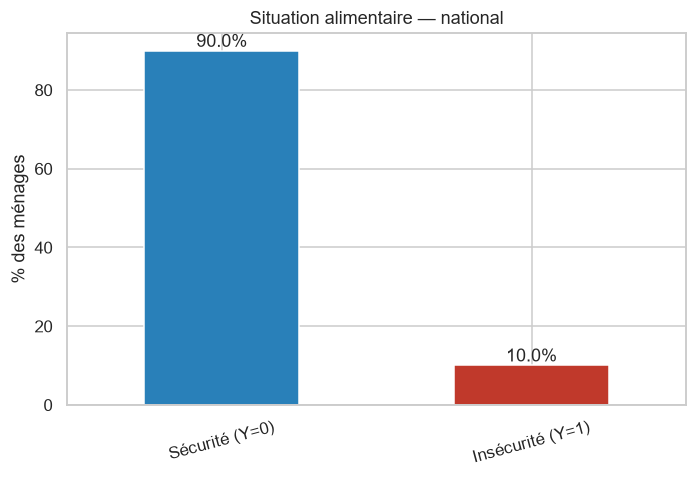

In [15]:
# Approche graphique (1/2) : diagramme en barres — répartition nationale
fig, ax = plt.subplots(figsize=(6.5, 4.5))
tab_y["% brut"].plot(kind="bar", ax=ax, color=["#2980b9", "#c0392b"], rot=15)
ax.set_xlabel("")
ax.set_ylabel("% des ménages"); ax.set_title("Situation alimentaire — national")
for i, v in enumerate(tab_y["% brut"]):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/univarie_Y_national.png", bbox_inches="tight"); plt.show()

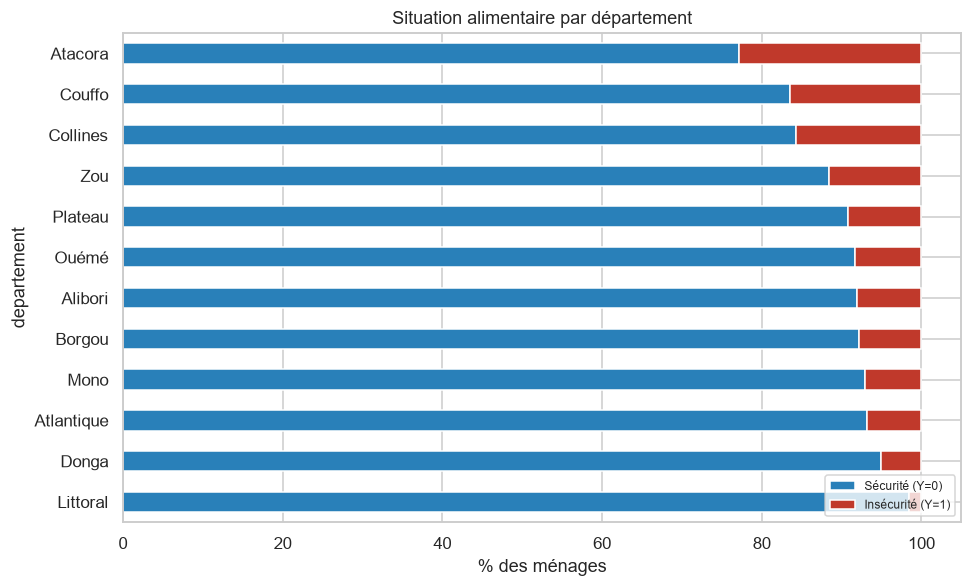

In [16]:
# Approche graphique (2/2) : barres empilées par département
fig, ax = plt.subplots(figsize=(9, 5.5))
share = (pd.crosstab(dep_lab_D, D["Y"], normalize="index") * 100).sort_values(1.0)
share.columns = [y_labels[c] for c in share.columns]
share.plot(kind="barh", stacked=True, ax=ax, color=["#2980b9", "#c0392b"])
ax.set_xlabel("% des ménages"); ax.set_title("Situation alimentaire par département")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/univarie_Y_departement.png", bbox_inches="tight"); plt.show()

#### b) Répartition de la taille des ménages

Taille du ménage — statistiques descriptives (globales et par milieu) :
            Ensemble   Urbain    Rural
n           14952.00  6856.00  8096.00
moyenne         6.83     6.40     7.20
médiane         6.00     6.00     6.00
écart-type      4.57     4.29     4.76
CV (%)         66.87    67.01    66.16
min             0.00     0.00     0.00
P10             2.00     2.00     2.00
P25             4.00     4.00     4.00
P75             8.00     8.00     9.00
P90            12.00    11.00    13.00
max            86.00    86.00    62.00
skewness        2.88     4.03     2.16
kurtosis       22.24    45.45     9.70


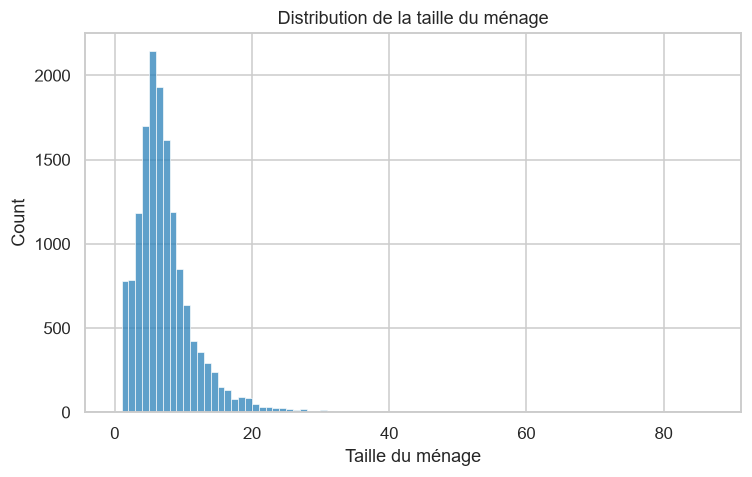

In [17]:
tab_taille = pd.DataFrame({
    "Ensemble": stats_desc(D["taille_menage"]),
    "Urbain":   stats_desc(D.loc[milieu_ur == "Urbain", "taille_menage"]),
    "Rural":    stats_desc(D.loc[milieu_ur == "Rural", "taille_menage"]),
}).round(2)
print("Taille du ménage — statistiques descriptives (globales et par milieu) :")
print(tab_taille.to_string())
tab_taille.to_csv(f"{OUT_DIR}/univarie_taille.csv")

# Histogramme de la distribution
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.histplot(D["taille_menage"], bins=range(0, int(D["taille_menage"].max()) + 2),
             ax=ax, color="#2980b9")
ax.set_xlabel("Taille du ménage"); ax.set_title("Distribution de la taille du ménage")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/univarie_taille_hist.png", bbox_inches="tight"); plt.show()

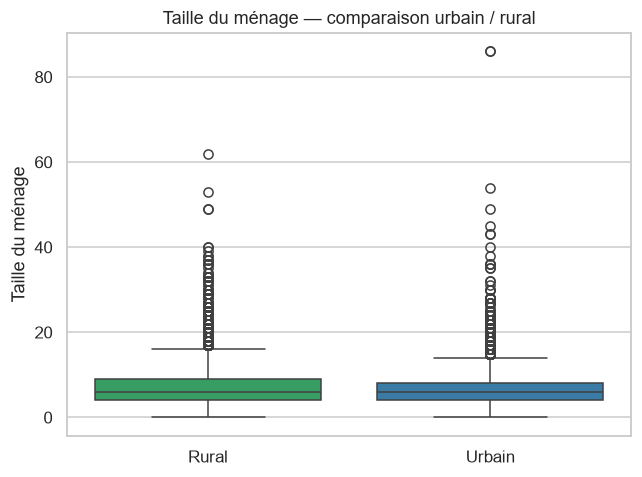

In [18]:
# Boîte à moustaches comparative urbain / rural
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.boxplot(x=milieu_ur.to_numpy(), y=D["taille_menage"].to_numpy(),
            hue=milieu_ur.to_numpy(), legend=False, ax=ax,
            palette={"Urbain": "#2980b9", "Rural": "#27ae60"})
ax.set_ylabel("Taille du ménage"); ax.set_title("Taille du ménage — comparaison urbain / rural")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/univarie_taille_boxplot.png", bbox_inches="tight"); plt.show()

#### c) Distribution du revenu

Revenu mensuel du ménage — échelle brute et log-transformée (§4.3.3) :
            Revenu brut (FCFA)  ln(revenu+1)
n                    14952.000     14952.000
moyenne              68105.045         8.282
médiane              15000.000         9.616
écart-type          217941.107         3.117
CV (%)                 320.007        37.641
min                      0.000         0.000
P10                     99.000         4.605
P25                    198.000         5.293
P75                  60000.000        11.002
P90                 145000.000        11.884
max                6000000.000        15.607
skewness                11.065        -0.059
kurtosis               181.846        -1.543


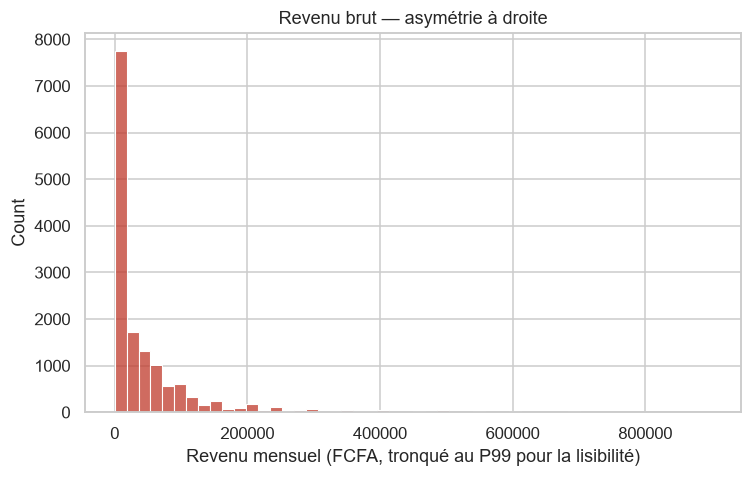

In [19]:
tab_rev = pd.DataFrame({
    "Revenu brut (FCFA)": stats_desc(revenu_brut),
    "ln(revenu+1)":       stats_desc(D["log_revenu"]),
}).round(3)
print("Revenu mensuel du ménage — échelle brute et log-transformée (§4.3.3) :")
print(tab_rev.to_string())
tab_rev.to_csv(f"{OUT_DIR}/univarie_revenu.csv")

# Histogramme du revenu brut (asymétrie à droite attendue)
fig, ax = plt.subplots(figsize=(7, 4.5))
lim99 = revenu_brut.quantile(0.99)
sns.histplot(revenu_brut[revenu_brut <= lim99], bins=50, ax=ax, color="#c0392b")
ax.set_xlabel("Revenu mensuel (FCFA, tronqué au P99 pour la lisibilité)")
ax.set_title("Revenu brut — asymétrie à droite")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/univarie_revenu_brut.png", bbox_inches="tight"); plt.show()

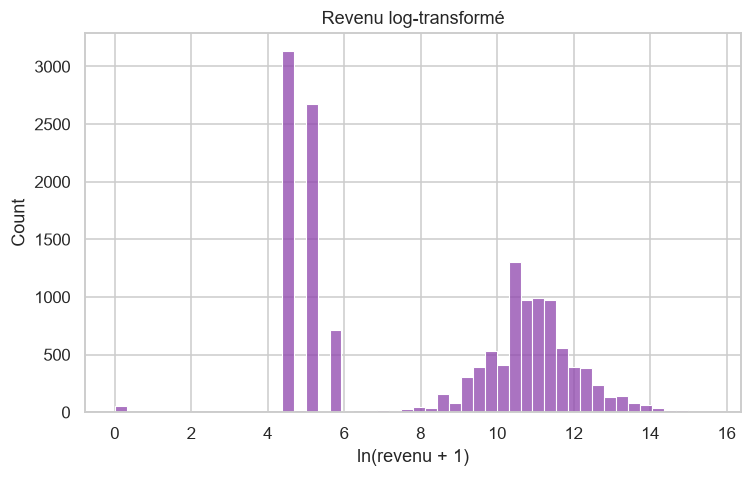

In [20]:
# Histogramme du revenu log-transformé (rapprochement vers la symétrie)
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.histplot(D["log_revenu"], bins=50, ax=ax, color="#8e44ad")
ax.set_xlabel("ln(revenu + 1)"); ax.set_title("Revenu log-transformé")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/univarie_revenu_log.png", bbox_inches="tight"); plt.show()

#### d) Distribution de l'âge du chef de ménage

Âge du chef de ménage — statistiques descriptives :
            Âge du CM
n            14952.00
moyenne         47.11
médiane         45.00
écart-type      14.99
CV (%)          31.83
min             16.00
P10             30.00
P25             35.00
P75             56.00
P90             68.00
max            100.00
skewness         0.70
kurtosis         0.33

Répartition par tranches d'âge usuelles :
                 Effectif      %
age_cm                          
Moins de 30 ans      1336   8.94
30–44 ans            5565  37.22
45–59 ans            4830  32.30
60 ans et +          3221  21.54


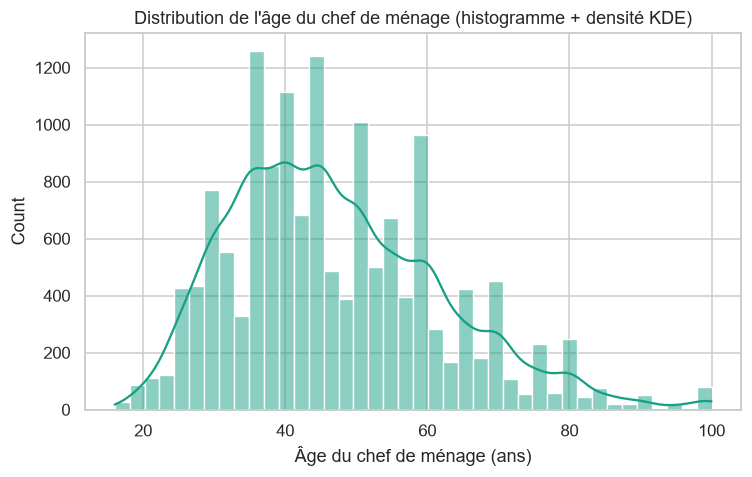

In [21]:
tab_age = stats_desc(D["age_cm"]).round(2).to_frame("Âge du CM")
print("Âge du chef de ménage — statistiques descriptives :")
print(tab_age.to_string())
tab_age.to_csv(f"{OUT_DIR}/univarie_age_stats.csv")

tranches_age = pd.cut(D["age_cm"], bins=[0, 29, 44, 59, np.inf],
                      labels=["Moins de 30 ans", "30–44 ans", "45–59 ans", "60 ans et +"])
tab_tranches = tranches_age.value_counts().sort_index().rename("Effectif").to_frame()
tab_tranches["%"] = (100 * tab_tranches["Effectif"] / tab_tranches["Effectif"].sum()).round(2)
print("\nRépartition par tranches d'âge usuelles :")
print(tab_tranches.to_string())
tab_tranches.to_csv(f"{OUT_DIR}/univarie_age_tranches.csv")

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.histplot(D["age_cm"], bins=40, kde=True, ax=ax, color="#16a085")
ax.set_xlabel("Âge du chef de ménage (ans)")
ax.set_title("Distribution de l'âge du chef de ménage (histogramme + densité KDE)")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/univarie_age.png", bbox_inches="tight"); plt.show()

#### e) Répartition du niveau d'instruction du chef de ménage

Modalités originales Q_1_09 (n renseignés = 14952) :
                    Effectif      %
Q_1_09                             
Aucun                   7659  51.22
Primaire                3378  22.59
Secondaire              2548  17.04
Supérieur                669   4.47
alphabétisation          502   3.36
Ecole Coranique          175   1.17
Autre (à préciser)        12   0.08
Cursus arabe               9   0.06

Recodage en 3 niveaux retenu pour la modélisation (Table 5) :
                 Effectif      %
instruction_cm                  
Aucun/informel       8357  55.89
Primaire             3378  22.59
Secondaire et +      3217  21.52


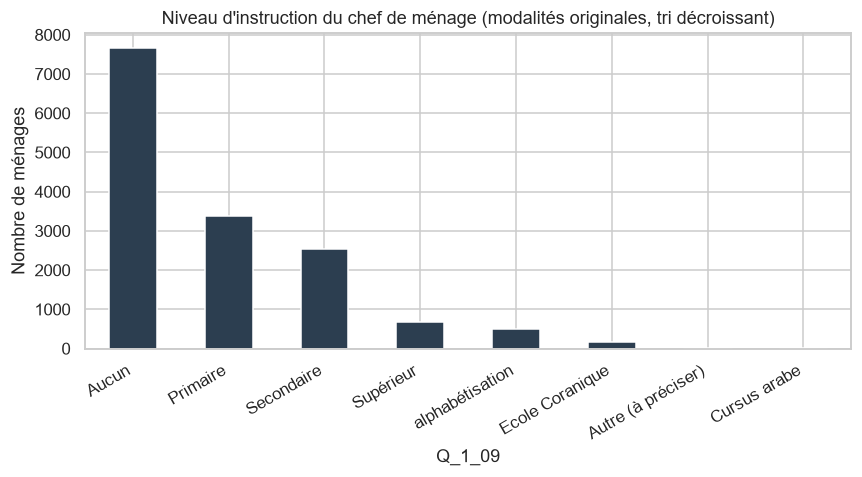

In [22]:
freq_q109 = q109.map(q109_labels).value_counts().rename("Effectif").to_frame()
freq_q109["%"] = (100 * freq_q109["Effectif"] / freq_q109["Effectif"].sum()).round(2)
print(f"Modalités originales Q_1_09 (n renseignés = {int(q109.notna().sum())}) :")
print(freq_q109.to_string())

freq_instr3 = (D["instruction_cm"].map(instr3_labels).value_counts()
               .reindex(list(instr3_labels.values())).rename("Effectif").to_frame())
freq_instr3["%"] = (100 * freq_instr3["Effectif"] / freq_instr3["Effectif"].sum()).round(2)
print("\nRecodage en 3 niveaux retenu pour la modélisation (Table 5) :")
print(freq_instr3.to_string())
freq_q109.to_csv(f"{OUT_DIR}/univarie_instruction.csv")

fig, ax = plt.subplots(figsize=(8, 4.5))
freq_q109["Effectif"].plot(kind="bar", ax=ax, color="#2c3e50", rot=30)
for lbl in ax.get_xticklabels():
    lbl.set_ha("right")
ax.set_ylabel("Nombre de ménages")
ax.set_title("Niveau d'instruction du chef de ménage (modalités originales, tri décroissant)")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/univarie_instruction.png", bbox_inches="tight"); plt.show()

#### f) Répartition des ménages ayant accès au crédit

Accès au crédit (emprunt au cours des 12 derniers mois, Q_6_02) :
credit      Non   Oui  Ensemble  % Oui brut  % Oui pondéré
Milieu                                                    
Rural      5885  2211      8096       27.31          27.85
Urbain     5211  1645      6856       23.99          24.63
Ensemble  11096  3856     14952       25.79          26.26


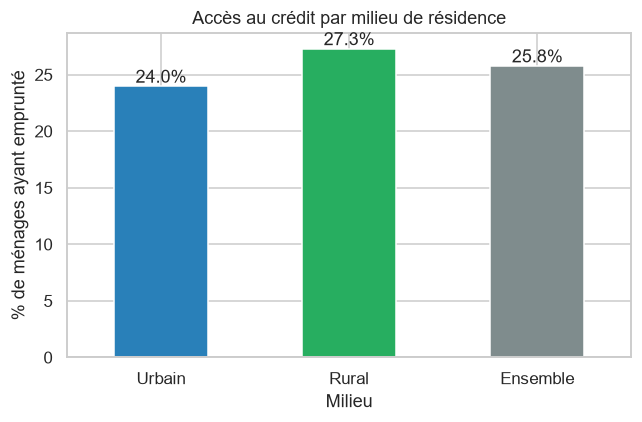

In [23]:
credit_lab = D["credit"].map({0.0: "Non", 1.0: "Oui"})
tab_credit = pd.crosstab(milieu_ur, credit_lab, margins=True, margins_name="Ensemble")
tab_credit["% Oui brut"] = (100 * tab_credit["Oui"]
                            / (tab_credit["Oui"] + tab_credit["Non"])).round(2)
for m in ("Urbain", "Rural"):
    sub = milieu_ur == m
    tab_credit.loc[m, "% Oui pondéré"] = round(
        100 * weighted_mean(D.loc[sub, "credit"], w_D[sub]), 2)
tab_credit.loc["Ensemble", "% Oui pondéré"] = round(100 * weighted_mean(D["credit"], w_D), 2)
print("Accès au crédit (emprunt au cours des 12 derniers mois, Q_6_02) :")
print(tab_credit.to_string())
tab_credit.to_csv(f"{OUT_DIR}/univarie_credit.csv")

fig, ax = plt.subplots(figsize=(6, 4))
tab_credit.loc[["Urbain", "Rural", "Ensemble"], "% Oui brut"].plot(
    kind="bar", ax=ax, color=["#2980b9", "#27ae60", "#7f8c8d"], rot=0)
ax.set_ylabel("% de ménages ayant emprunté")
ax.set_title("Accès au crédit par milieu de résidence")
for i, v in enumerate(tab_credit.loc[["Urbain", "Rural", "Ensemble"], "% Oui brut"]):
    ax.text(i, v + 0.3, f"{v:.1f}%", ha="center")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/univarie_credit.png", bbox_inches="tight"); plt.show()

### 5.2 Test de normalité des variables continues (§4.4.3)

H₀ : la variable suit une loi normale 𝒩(μ, σ²). Test de **Kolmogorov-Smirnov** sur la
variable standardisée (Dₙ = sup|Fₙ − Φ|), complété par **Shapiro-Wilk** (sous-échantillon
de 5 000 obs.) et par les coefficients de **skewness/kurtosis** + **QQ-plots** : avec
n ≈ 15 000, le test KS rejette quasi systématiquement H₀ même pour des écarts mineurs
(précaution du §4.4.3) — la décision s'appuie donc aussi sur l'examen graphique.
`p ≤ 0,05` ⇒ normalité rejetée ⇒ test non paramétrique de Mann-Whitney en §5.3.

Tests de normalité (§4.4.3) :
             variable     n   KS_D  KS_p  Shapiro_W  Shapiro_p  skewness  kurtosis                  conclusion
     Taille du ménage 14952 0.1642   0.0     0.8128        0.0    2.8825   22.2429 rejetée -> non paramétrique
   Revenu brut (FCFA) 14952 0.3773   0.0     0.2674        0.0   11.0649  181.8455 rejetée -> non paramétrique
         ln(revenu+1) 14952 0.2393   0.0     0.8485        0.0   -0.0591   -1.5428 rejetée -> non paramétrique
Âge du chef de ménage 14952 0.0916   0.0     0.9688        0.0    0.7037    0.3288 rejetée -> non paramétrique


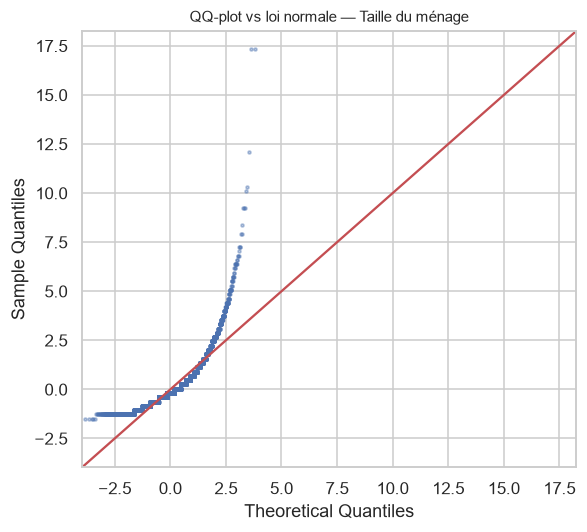

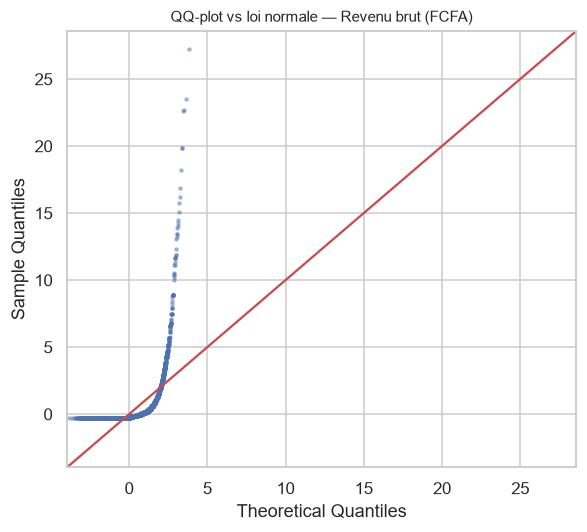

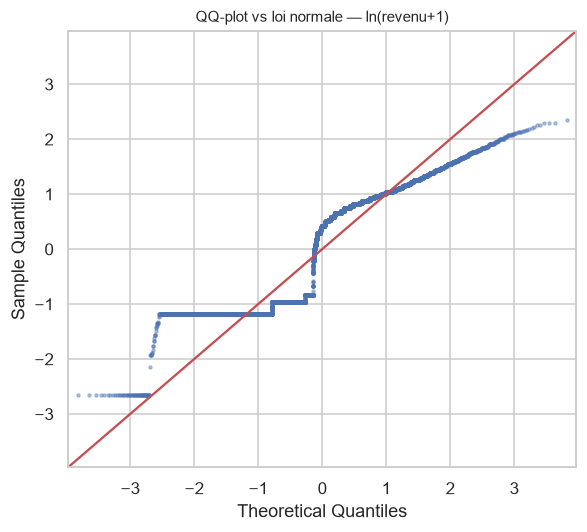

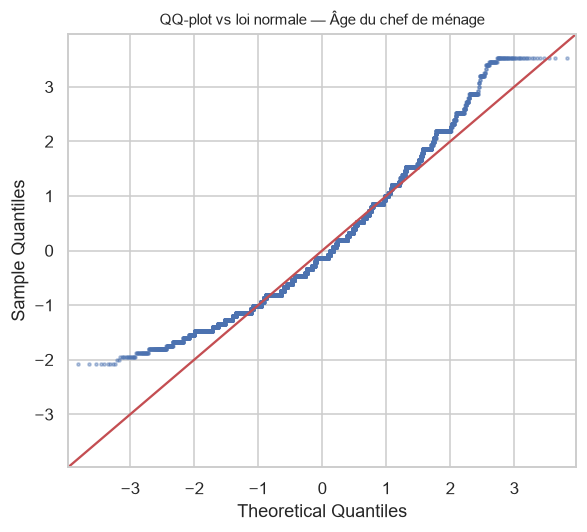

In [24]:
norm_candidates = {
    "Taille du ménage":      D["taille_menage"],
    "Revenu brut (FCFA)":    revenu_brut,
    "ln(revenu+1)":          D["log_revenu"],
    "Âge du chef de ménage": D["age_cm"],
}
rng = np.random.default_rng(RANDOM_STATE)
norm_rows, NORMALITY = [], {}
for name, s in norm_candidates.items():
    x = pd.to_numeric(s, errors="coerce").dropna().values
    z = (x - x.mean()) / x.std(ddof=1)
    ks_D, ks_p = stats.kstest(z, "norm")
    W_sh, p_sh = stats.shapiro(rng.choice(x, size=min(5000, len(x)), replace=False))
    NORMALITY[name] = ks_p > 0.05
    norm_rows.append((name, len(x), ks_D, ks_p, W_sh, p_sh,
                      stats.skew(x), stats.kurtosis(x),
                      "normalité acceptable" if NORMALITY[name] else "rejetée -> non paramétrique"))
norm_tab = pd.DataFrame(norm_rows, columns=["variable", "n", "KS_D", "KS_p", "Shapiro_W",
                                            "Shapiro_p", "skewness", "kurtosis", "conclusion"])
print("Tests de normalité (§4.4.3) :")
print(norm_tab.round(4).to_string(index=False))
norm_tab.to_csv(f"{OUT_DIR}/normalite_tests.csv", index=False)

# QQ-plots — examen graphique complémentaire (une figure par variable)
qq_slugs = {"Taille du ménage": "taille", "Revenu brut (FCFA)": "revenu_brut",
            "ln(revenu+1)": "revenu_log", "Âge du chef de ménage": "age"}
for name, s in norm_candidates.items():
    x = pd.to_numeric(s, errors="coerce").dropna().values
    fig, ax = plt.subplots(figsize=(5.5, 5))
    sm.qqplot((x - x.mean()) / x.std(ddof=1), line="45", ax=ax, markersize=2, alpha=0.4)
    ax.set_title(f"QQ-plot vs loi normale — {name}", fontsize=10)
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/normalite_qq_{qq_slugs[name]}.png", bbox_inches="tight")
    plt.show()

### 5.3 Analyse bivariée : variables focales × situation alimentaire (§4.4.4)

Canevas du mémoire pour chaque variable focale :

- **continue** (b' taille, c' revenu, d' âge) : test de **Levene** (homoscédasticité) →
  t de Student (ou **Welch** si p_Levene ≤ 0,05) si normalité acceptée, sinon
  **Mann-Whitney** ; tableau comparatif par statut Y + boîte à moustaches ;
- **catégorielle** (e' instruction) : **χ²** d'indépendance + **V de Cramér**
  (validité : E_ij ≥ 5 dans ≥ 80 % des cellules, sinon test exact de Fisher) ;
- **binaire 2×2** (f' crédit) : Fisher exact par défaut si un effectif théorique < 5 ;
  **odds ratio brut** avec IC à 95 %.

Les p-valeurs de ces tests alimentent la synthèse corrigée FDR de la §5.4.

In [25]:
FOCAL_TESTS = []   # (variable, test, statistique, p) — repris dans la synthèse §5.4

def bivar_continu(nom, s, normal):
    """Canevas §4.4.4 pour une variable continue : Levene puis t/Welch ou Mann-Whitney."""
    g0 = pd.to_numeric(s[D["Y"] == 0], errors="coerce").dropna()
    g1 = pd.to_numeric(s[D["Y"] == 1], errors="coerce").dropna()
    lev_W, lev_p = stats.levene(g0, g1)
    if normal:
        test = "t de Student" if lev_p > 0.05 else "t de Welch"
        stat, p = stats.ttest_ind(g1, g0, equal_var=lev_p > 0.05)
    else:
        test = "Mann-Whitney"
        stat, p = stats.mannwhitneyu(g1, g0, alternative="two-sided")
    tab = pd.DataFrame({"Sécurité (Y=0)":   [len(g0), g0.mean(), g0.median(), g0.std()],
                        "Insécurité (Y=1)": [len(g1), g1.mean(), g1.median(), g1.std()]},
                       index=["n", "moyenne", "médiane", "écart-type"]).round(2)
    print(f"—— {nom} × Y ——")
    print(tab.to_string())
    print(f"Levene : W={lev_W:.2f} (p={lev_p:.3g}) -> {test} : stat={stat:,.1f}, p={p:.3g}"
          f"  [{'différence significative' if p < 0.05 else 'différence non significative'}]\n")
    FOCAL_TESTS.append((nom, test, stat, p))
    return tab

# b') Taille du ménage × Y — c') ln(revenu+1) × Y — d') Âge du CM × Y
tab_taille_y = bivar_continu("Taille du ménage", D["taille_menage"],
                             NORMALITY["Taille du ménage"])
tab_rev_y    = bivar_continu("ln(revenu+1)", D["log_revenu"], NORMALITY["ln(revenu+1)"])
tab_age_y    = bivar_continu("Âge du chef de ménage", D["age_cm"],
                             NORMALITY["Âge du chef de ménage"])

# c') complément de présentation : revenu à l'échelle brute par statut Y
rev_brut_y = pd.DataFrame({
    "Sécurité (Y=0)":   stats_desc(revenu_brut[D["Y"] == 0])[["moyenne", "médiane", "écart-type"]],
    "Insécurité (Y=1)": stats_desc(revenu_brut[D["Y"] == 1])[["moyenne", "médiane", "écart-type"]],
}).round(0)
print("Revenu à l'échelle brute (FCFA) par statut Y (le test porte sur l'échelle log) :")
print(rev_brut_y.to_string())

# d') complément : tableau croisé tranches d'âge × Y (effectifs et % en ligne)
ct_age = pd.crosstab(tranches_age, D["Y"].map(y_labels))
ct_age_pct = pd.crosstab(tranches_age, D["Y"].map(y_labels), normalize="index").mul(100).round(2)
print("\nTranches d'âge × situation alimentaire (effectifs, puis % en ligne) :")
print(pd.concat([ct_age, ct_age_pct.add_suffix(" (%)")], axis=1).to_string())

—— Taille du ménage × Y ——
            Sécurité (Y=0)  Insécurité (Y=1)
n                 13450.00           1502.00
moyenne               6.87              6.54
médiane               6.00              6.00
écart-type            4.59              4.38
Levene : W=0.02 (p=0.894) -> Mann-Whitney : stat=9,667,365.5, p=0.00604  [différence significative]

—— ln(revenu+1) × Y ——
            Sécurité (Y=0)  Insécurité (Y=1)
n                 13450.00           1502.00
moyenne               8.37              7.50
médiane               9.63              5.70
écart-type            3.13              2.84
Levene : W=24.05 (p=9.48e-07) -> Mann-Whitney : stat=8,119,697.0, p=2.69e-36  [différence significative]

—— Âge du chef de ménage × Y ——
            Sécurité (Y=0)  Insécurité (Y=1)
n                 13450.00           1502.00
moyenne              46.93             48.69
médiane              45.00             45.00
écart-type           14.81             16.49
Levene : W=31.46 (p=2.07e-08) -> Man

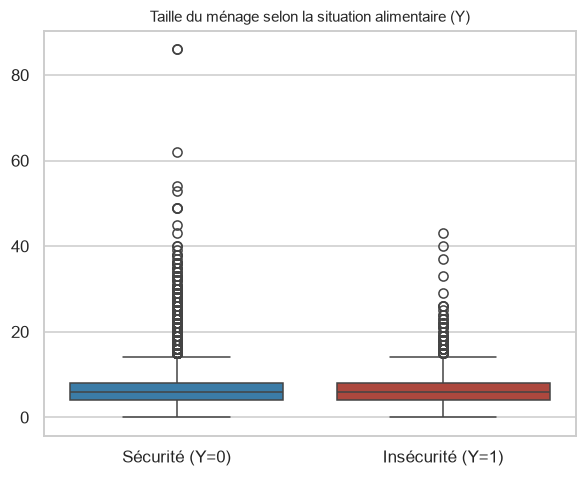

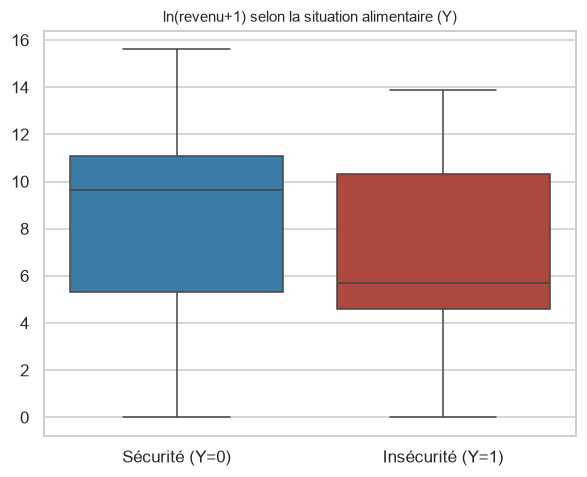

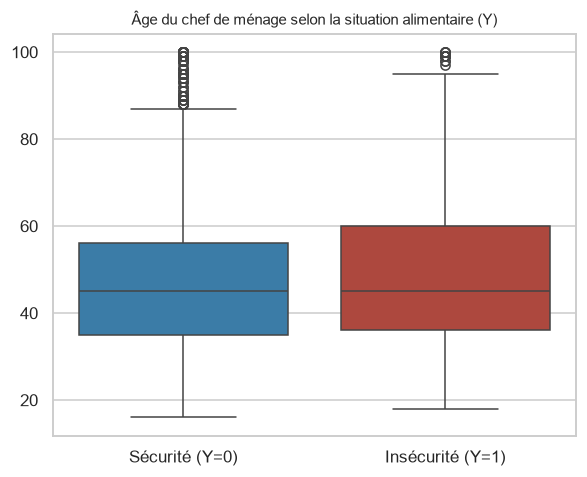

In [26]:
# Boîtes à moustaches comparatives (présentation §4.4.4 b'–d') — une figure par variable
y_lab_D = D["Y"].map(y_labels)
palette_y = {y_labels[0.0]: "#2980b9", y_labels[1.0]: "#c0392b"}
bx_slugs = {"Taille du ménage": "taille", "ln(revenu+1)": "revenu",
            "Âge du chef de ménage": "age"}
for nom, s in [("Taille du ménage", D["taille_menage"]),
               ("ln(revenu+1)", D["log_revenu"]),
               ("Âge du chef de ménage", D["age_cm"])]:
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    sns.boxplot(x=y_lab_D.to_numpy(), y=s.to_numpy(), hue=y_lab_D.to_numpy(),
                palette=palette_y, legend=False, ax=ax)
    ax.set_title(f"{nom} selon la situation alimentaire (Y)", fontsize=10)
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/bivarie_boxplot_{bx_slugs[nom]}.png", bbox_inches="tight")
    plt.show()

Niveau d'instruction × Y (effectifs, puis % en ligne) :
Y                Insécurité (Y=1)  Sécurité (Y=0)  Insécurité (Y=1) (%)  Sécurité (Y=0) (%)
instruction_cm                                                                             
Aucun/informel               1101            7256                 13.17               86.83
Primaire                      261            3117                  7.73               92.27
Secondaire et +               140            3077                  4.35               95.65

Validité : 100 % des cellules avec effectif théorique >= 5 (Chi2 applicable)
Chi2(2) = 226.06, p = 8.15e-50 | V de Cramér = 0.123 [association significative]


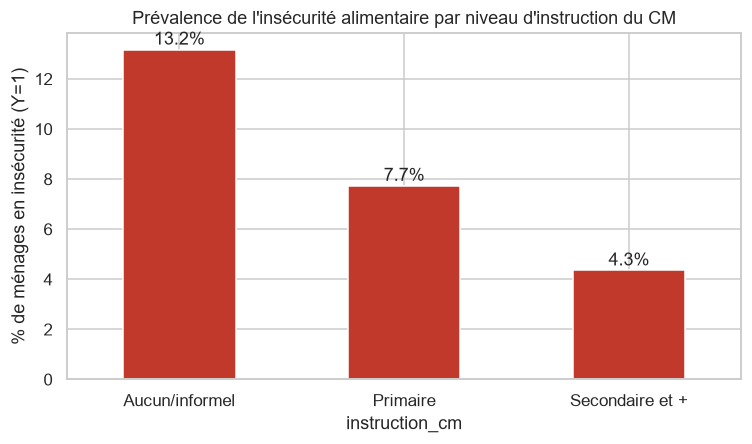

In [27]:
# e') Niveau d'instruction (3 niveaux) × Y : χ² + V de Cramér
instr_lab = D["instruction_cm"].map(instr3_labels)
ct_i = pd.crosstab(instr_lab, D["Y"].map(y_labels)).reindex(list(instr3_labels.values()))
chi2_i, p_i, dof_i, exp_i = stats.chi2_contingency(ct_i)
valid_i = (exp_i >= 5).mean()
V_i = np.sqrt(chi2_i / (ct_i.values.sum() * (min(ct_i.shape) - 1)))
pct_i = pd.crosstab(instr_lab, D["Y"].map(y_labels), normalize="index") \
          .mul(100).round(2).reindex(list(instr3_labels.values()))
print("Niveau d'instruction × Y (effectifs, puis % en ligne) :")
print(pd.concat([ct_i, pct_i.add_suffix(" (%)")], axis=1).to_string())
print(f"\nValidité : {valid_i*100:.0f} % des cellules avec effectif théorique >= 5 "
      f"({'Chi2 applicable' if valid_i >= 0.8 else 'recours au test exact de Fisher'})")
print(f"Chi2({dof_i}) = {chi2_i:.2f}, p = {p_i:.3g} | V de Cramér = {V_i:.3f} "
      f"[{'association significative' if p_i < 0.05 else 'ns'}]")
FOCAL_TESTS.append(("Niveau d'instruction (3 niveaux)", "Chi2", chi2_i, p_i))

fig, ax = plt.subplots(figsize=(7, 4.2))
pct_i[y_labels[1.0]].plot(kind="bar", ax=ax, color="#c0392b", rot=0)
ax.set_ylabel("% de ménages en insécurité (Y=1)")
ax.set_title("Prévalence de l'insécurité alimentaire par niveau d'instruction du CM")
for i, v in enumerate(pct_i[y_labels[1.0]]):
    ax.text(i, v + 0.2, f"{v:.1f}%", ha="center")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/bivarie_instruction.png", bbox_inches="tight"); plt.show()

Accès au crédit × Y (tableau 2×2, puis % en ligne) :
Y       Insécurité (Y=1)  Sécurité (Y=0)  Insécurité (Y=1) (%)  Sécurité (Y=0) (%)
credit                                                                            
Oui                  385            3471                  9.98               90.02
Non                 1117            9979                 10.07               89.93

Effectifs théoriques minimaux : 387.4 -> test retenu : Chi2
Chi2 : stat=0.013, p=0.908 [ns]
Odds ratio brut (crédit -> insécurité) : OR = 0.991, IC 95 % = [0.877 ; 1.120]


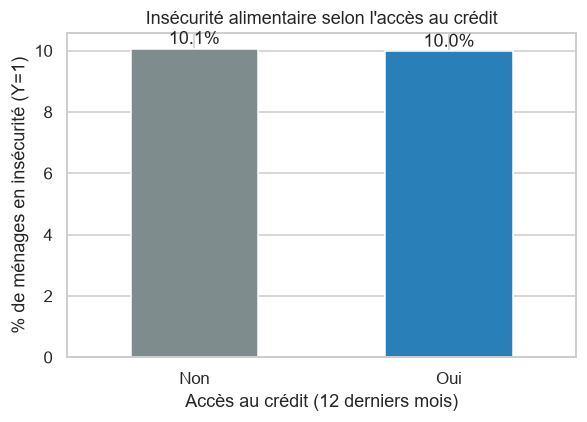


Synthèse des tests focaux enregistrée : outputs/bivarie_focales.csv


In [28]:
# f') Accès au crédit × Y : tableau 2×2, χ² ou Fisher exact + odds ratio brut (IC 95 %)
ct_c = pd.crosstab(credit_lab, D["Y"].map(y_labels)).reindex(["Oui", "Non"])
exp_c = stats.chi2_contingency(ct_c)[3]
# Orientation OR : lignes = crédit (Oui, Non), colonnes = (Y=1, Y=0) -> OR = (a·d)/(b·c)
t22 = np.array([[ct_c.loc["Oui", y_labels[1.0]], ct_c.loc["Oui", y_labels[0.0]]],
                [ct_c.loc["Non", y_labels[1.0]], ct_c.loc["Non", y_labels[0.0]]]], dtype=float)
if (exp_c < 5).any():
    stat_c, p_c = stats.fisher_exact(t22)
    test_c = "Fisher exact"
else:
    stat_c, p_c, _, _ = stats.chi2_contingency(ct_c)
    test_c = "Chi2"
tab22 = sm.stats.Table2x2(t22)
or_brut = tab22.oddsratio
or_lo, or_hi = tab22.oddsratio_confint()
pct_c = pd.crosstab(credit_lab, D["Y"].map(y_labels), normalize="index").mul(100).round(2)
print("Accès au crédit × Y (tableau 2×2, puis % en ligne) :")
print(pd.concat([ct_c, pct_c.reindex(["Oui", "Non"]).add_suffix(" (%)")], axis=1).to_string())
print(f"\nEffectifs théoriques minimaux : {exp_c.min():.1f} -> test retenu : {test_c}")
print(f"{test_c} : stat={stat_c:.3f}, p={p_c:.3g} "
      f"[{'association significative' if p_c < 0.05 else 'ns'}]")
print(f"Odds ratio brut (crédit -> insécurité) : OR = {or_brut:.3f}, "
      f"IC 95 % = [{or_lo:.3f} ; {or_hi:.3f}]")
FOCAL_TESTS.append(("Accès au crédit", test_c, stat_c, p_c))

fig, ax = plt.subplots(figsize=(5.5, 4))
pct_c.loc[["Non", "Oui"], y_labels[1.0]].plot(kind="bar", ax=ax,
                                              color=["#7f8c8d", "#2980b9"], rot=0)
ax.set_xlabel("Accès au crédit (12 derniers mois)")
ax.set_ylabel("% de ménages en insécurité (Y=1)")
ax.set_title("Insécurité alimentaire selon l'accès au crédit")
for i, v in enumerate(pct_c.loc[["Non", "Oui"], y_labels[1.0]]):
    ax.text(i, v + 0.15, f"{v:.1f}%", ha="center")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/bivarie_credit.png", bbox_inches="tight"); plt.show()

pd.DataFrame(FOCAL_TESTS, columns=["variable", "test", "statistique", "p_value"]) \
  .to_csv(f"{OUT_DIR}/bivarie_focales.csv", index=False)
print("\nSynthèse des tests focaux enregistrée : outputs/bivarie_focales.csv")

### 5.4 Tests bivariés étendus à l'ensemble des variables + correction FDR

L'analyse est étendue « de façon plus synthétique » à l'ensemble des variables
indépendantes (Table 10) : Mann-Whitney pour les continues (normalité rejetée en §5.2)
et χ² + V de Cramér pour les catégorielles. L'ensemble des p-valeurs (les variables
focales de la §5.3 y sont incluses) est corrigé par **Benjamini-Hochberg** (contrôle du
FDR) ; le tableau de synthèse rapporte test, statistique, p brute, p ajustée, conclusion.

In [29]:
def cramers_v(confusion):
    chi2 = stats.chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    r, k = confusion.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

continu_vars = ["age_cm", "taille_menage", "ratio_dependance", "log_revenu",
                "log_depenses_alim", "tlu", "diversification_revenus", "indice_logement",
                "mois_couverture_stocks"]
categ_vars   = ["sexe_cm", "rural", "credit", "instruction_cm", "eau_amelioree",
                "electricite", "securite_fonciere", "choc_subi", "assistance_recue",
                "activite_principale", "type_choc", "departement", "semences_ameliorees"]

results = []
for v in continu_vars:
    g0 = D.loc[D.Y == 0, v].dropna()
    g1 = D.loc[D.Y == 1, v].dropna()
    u, p = stats.mannwhitneyu(g1, g0, alternative="two-sided")
    results.append((v, "Mann-Whitney", u, p, f"med0={g0.median():.2f} / med1={g1.median():.2f}"))

for v in categ_vars:
    ct = pd.crosstab(D[v], D.Y)
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    results.append((v, "Chi2", chi2, p, f"CramerV={cramers_v(ct):.3f}"))

res = pd.DataFrame(results, columns=["variable", "test", "statistique", "p_value", "effet"])
res["p_adj_FDR"] = multipletests(res["p_value"], method="fdr_bh")[1]
res["conclusion"] = np.where(res["p_adj_FDR"] < 0.05, "association significative", "ns")
res = res.sort_values("p_adj_FDR").reset_index(drop=True)
print("Synthese des tests bivaries (variable x Y), correction FDR de Benjamini-Hochberg :")
print(res.round(4).to_string(index=False))
res.to_csv(f"{OUT_DIR}/tests_bivaries.csv", index=False)

Synthese des tests bivaries (variable x Y), correction FDR de Benjamini-Hochberg :
               variable         test  statistique  p_value                   effet  p_adj_FDR                conclusion
      log_depenses_alim Mann-Whitney 6.454472e+06   0.0000   med0=9.99 / med1=9.29     0.0000 association significative
            electricite         Chi2 4.282460e+02   0.0000           CramerV=0.169     0.0000 association significative
            departement         Chi2 4.768330e+02   0.0000           CramerV=0.179     0.0000 association significative
        indice_logement Mann-Whitney 7.311971e+06   0.0000   med0=3.00 / med1=2.00     0.0000 association significative
         instruction_cm         Chi2 2.260621e+02   0.0000           CramerV=0.123     0.0000 association significative
                  rural         Chi2 1.972274e+02   0.0000           CramerV=0.115     0.0000 association significative
             log_revenu Mann-Whitney 8.119697e+06   0.0000   med0=9.63 / med1

### Construction de la matrice de conception (encodage one-hot)

In [30]:
CAT_POLY = ["statut_matrimonial", "departement", "activite_principale", "type_choc"]
NUM_FEATS = [c for c in D.columns
             if c not in CAT_POLY + DESIGN_COLS]

# References des polytomiques : Atlantique (dept 3), Marie (statut 2)
X_all = pd.get_dummies(D[NUM_FEATS + CAT_POLY], columns=CAT_POLY,
                       drop_first=True, dtype=float)
y_all      = D["Y"].astype(int).values
groups_all = D["grappe"].values
w_all      = D["weight"].values

print("Matrice de conception X :", X_all.shape)
print("Apercu des predicteurs :", list(X_all.columns)[:12], "...")

Matrice de conception X : (14952, 58)
Apercu des predicteurs : ['sexe_cm', 'age_cm', 'instruction_cm', 'taille_menage', 'ratio_dependance', 'taux_scolarisation', 'rural', 'indice_logement', 'eau_amelioree', 'electricite', 'toilette_amelioree', 'temps_eau'] ...


In [31]:
# VIF (multicolinearite) sur les predicteurs numeriques continus
vif_vars = ["age_cm", "taille_menage", "ratio_dependance", "log_revenu",
            "log_depenses_alim", "tlu", "diversification_revenus", "indice_logement",
            "contribution_principale", "nb_contributeurs", "temps_eau",
            "mois_couverture_stocks"]
Xv = sm.add_constant(D[vif_vars].astype(float))
vif = pd.DataFrame({
    "variable": vif_vars,
    "VIF": [variance_inflation_factor(Xv.values, i + 1) for i in range(len(vif_vars))]
}).sort_values("VIF", ascending=False)
print("Facteurs d'inflation de la variance (VIF) :")
print(vif.to_string(index=False))
print("\nRegle : VIF<5 acceptable | 5-10 surveillance | >10 severe")

Facteurs d'inflation de la variance (VIF) :
               variable      VIF
diversification_revenus 1.821473
contribution_principale 1.703954
          taille_menage 1.249696
 mois_couverture_stocks 1.217135
        indice_logement 1.189069
       nb_contributeurs 1.156939
              temps_eau 1.140102
      log_depenses_alim 1.138517
             log_revenu 1.057599
                    tlu 1.052771
       ratio_dependance 1.039605
                 age_cm 1.035699

Regle : VIF<5 acceptable | 5-10 surveillance | >10 severe


### GVIF — variables polytomiques (§4.4.5)

Le VIF classique n'étant valide que pour des prédicteurs continus, le **GVIF** de
Fox & Monette (1992) est calculé pour les polytomiques (département, statut matrimonial,
activité principale, type de choc) et interprété via sa forme normalisée
**gvif^(1/(2·df))**, comparable au seuil du VIF usuel (√5 ≈ 2,24 ; √10 ≈ 3,16).

In [32]:
_corr = np.corrcoef(X_all.astype(float).values, rowvar=False)
_cols_x = list(X_all.columns)

def _logdet(M):
    return np.linalg.slogdet(M)[1]

def gvif_group(group_cols):
    i1 = [_cols_x.index(c) for c in group_cols]
    i2 = [i for i in range(len(_cols_x)) if i not in i1]
    return float(np.exp(_logdet(_corr[np.ix_(i1, i1)]) + _logdet(_corr[np.ix_(i2, i2)])
                        - _logdet(_corr)))

gvif_rows = []
for v in CAT_POLY:
    grp = [c for c in _cols_x if c.startswith(v + "_")]
    if not grp:
        continue
    g = gvif_group(grp)
    gvif_rows.append((v, len(grp), g, g ** (1 / (2 * len(grp)))))
gvif_tab = pd.DataFrame(gvif_rows, columns=["variable", "df", "GVIF", "GVIF^(1/(2df))"])
print("GVIF des variables polytomiques (Fox & Monette 1992) :")
print(gvif_tab.round(3).to_string(index=False))
print("\nRegle : GVIF^(1/(2df)) < 2,24 acceptable | 2,24-3,16 surveillance | > 3,16 severe")

GVIF des variables polytomiques (Fox & Monette 1992) :
           variable  df    GVIF  GVIF^(1/(2df))
 statut_matrimonial   5   2.155           1.080
        departement  11   6.231           1.087
activite_principale   5   5.163           1.178
          type_choc   4 102.411           1.784

Regle : GVIF^(1/(2df)) < 2,24 acceptable | 2,24-3,16 surveillance | > 3,16 severe


### Test de Box-Tidwell — linéarité dans le logit (§4.5.3)

Pour chaque prédicteur continu strictement positif, on ajoute le terme `X·ln(X)` au modèle
et on teste sa significativité (Wald). `p < 0,05` ⇒ relation non linéaire dans le logit
(les algorithmes d'arbres, non paramétriques, ne sont pas concernés).

In [33]:
bt_vars = ["age_cm", "taille_menage", "log_depenses_alim", "ratio_dependance"]
bt_rows = []
X_bt_base = D[["age_cm", "taille_menage", "log_depenses_alim", "ratio_dependance",
               "log_revenu", "indice_logement", "rural"]].astype(float)
for v in bt_vars:
    xv = D[v].astype(float).clip(lower=1e-6) + (1.0 if (D[v] <= 0).any() else 0.0)  # décalage si zéros
    Xbt = X_bt_base.copy()
    Xbt[f"{v}_lnx"] = xv * np.log(xv)
    try:
        fit_bt = sm.GLM(D["Y"].astype(int), sm.add_constant(Xbt),
                        family=sm.families.Binomial()).fit(maxiter=200)
        p_bt = fit_bt.pvalues[f"{v}_lnx"]
        bt_rows.append((v, p_bt, "non linéaire -> transformation/spline" if p_bt < 0.05 else "linéarité acceptable"))
    except Exception as e:
        bt_rows.append((v, np.nan, f"échec : {e}"))
bt_res = pd.DataFrame(bt_rows, columns=["variable", "p (X·lnX)", "conclusion"])
print("Test de Box-Tidwell :")
print(bt_res.to_string(index=False))
print("\nNB : avec n≈15 000, des écarts mineurs à la linéarité deviennent significatifs ;",
      "\nles termes concernés sont capturés par les modèles d'arbres (RF/XGBoost).")

Test de Box-Tidwell :


         variable    p (X·lnX)                            conclusion
           age_cm 6.064014e-01                  linéarité acceptable
    taille_menage 2.138902e-01                  linéarité acceptable
log_depenses_alim 3.871093e-18 non linéaire -> transformation/spline
 ratio_dependance 1.080386e-01                  linéarité acceptable

NB : avec n≈15 000, des écarts mineurs à la linéarité deviennent significatifs ; 
les termes concernés sont capturés par les modèles d'arbres (RF/XGBoost).


### 5.6 Version pondérée (design-based) des statistiques et tests bivariés (§4.5.1)

Par cohérence avec l'intégration des poids d'enquête dans les modèles (§4.5.4–4.5.5) et la
cartographie (§4.9), les statistiques descriptives et les tests bivariés de la Section 4.4
sont **recalculés en tenant compte du plan de sondage complexe** — poids `weight_agvsa`,
grappes `grappe` (unités primaires d'échantillonnage), strates reconstruites
`département × milieu` (le plan AGVSAN est stratifié ainsi ; aucune variable de strate
explicite n'est fournie dans la base) — via le package `samplics` (estimateurs de
linéarisation de Taylor, équivalent Python le plus proche de `survey` sous R).

- **Moyennes / proportions pondérées** : `samplics.TaylorEstimator` fournit le point et
  l'**IC à 95 % design-based**.
- **Tests bivariés** : pour les variables **continues** et **binaires**, comparaison
  design-based des moyennes / proportions par statut `Y` (estimation par domaine + test *z*
  sur la différence, variances de Taylor tenant compte des grappes et strates) ; pour les
  variables **polytomiques**, `samplics` ne fournit pas de test exploitable (la correction
  de Rao-Scott de cette version archivée renvoie des valeurs manquantes), le test est alors
  calculé — conformément à la limite reconnue du mémoire — par **repondération simple des
  effectifs** (χ² de `scipy` sur le tableau pondéré normalisé), avec signalement explicite.
- Les p-valeurs pondérées sont **confrontées** aux p-valeurs non pondérées (§5.4).

In [34]:
from samplics.estimation import TaylorEstimator
from samplics.utils.types import PopParam

# ---- Objets de plan de sondage (échantillon analytique D) ----
_w   = D["weight"].to_numpy(dtype=float)
_psu = D["grappe"].to_numpy()
_str = (D["departement"].astype(int).astype(str) + "_"
        + D["rural"].astype(int).astype(str)).to_numpy()
_Y   = D["Y"].to_numpy(dtype=float)

def _wprop_ci(binary_series):
    """Proportion pondérée design-based d'une variable 0/1 + IC 95 % (Taylor)."""
    est = TaylorEstimator(PopParam.prop)
    est.estimate(y=pd.Series(binary_series).map({0: "n", 1: "o"}).to_numpy(),
                 samp_weight=_w, psu=_psu, stratum=_str, remove_nan=True)
    return est.point_est.get("o", np.nan), est.lower_ci.get("o", np.nan), est.upper_ci.get("o", np.nan)

def _wmean_by_Y(series):
    """Moyenne pondérée design-based par groupe Y + p (test z sur la différence)."""
    est = TaylorEstimator(PopParam.mean)
    est.estimate(y=pd.Series(series).to_numpy(dtype=float),
                 samp_weight=_w, psu=_psu, stratum=_str, domain=_Y, remove_nan=True)
    m0, m1 = est.point_est[0.0], est.point_est[1.0]
    s0, s1 = est.stderror[0.0], est.stderror[1.0]
    z = (m1 - m0) / np.sqrt(s0**2 + s1**2)
    return m0, m1, 2 * (1 - stats.norm.cdf(abs(z)))

def _wprop_by_Y(binary_series):
    """Proportion pondérée design-based (modalité 1) par groupe Y + p (test z)."""
    est = TaylorEstimator(PopParam.prop)
    est.estimate(y=pd.Series(binary_series).map({0: "n", 1: "o"}).to_numpy(),
                 samp_weight=_w, psu=_psu, stratum=_str, domain=_Y, remove_nan=True)
    p0 = est.point_est[0.0].get("o", np.nan); p1 = est.point_est[1.0].get("o", np.nan)
    s0 = est.stderror[0.0].get("o", np.nan);  s1 = est.stderror[1.0].get("o", np.nan)
    z = (p1 - p0) / np.sqrt(s0**2 + s1**2)
    return p0, p1, 2 * (1 - stats.norm.cdf(abs(z)))

def _wchi2_reweight(catvar):
    """Fallback polytomique : χ² sur tableau pondéré normalisé (repondération simple)."""
    wn = _w * len(_w) / _w.sum()          # poids normalisés (somme = n)
    tmp = pd.DataFrame({"v": D[catvar].to_numpy(), "Y": _Y, "w": wn})
    ct = tmp.pivot_table(index="v", columns="Y", values="w", aggfunc="sum", fill_value=0)
    chi2, p, _, _ = stats.chi2_contingency(ct.values)
    return chi2, p

In [35]:
# ---- Statistiques univariées pondérées design-based (IC 95 % de Taylor) ----
uni_rows = []
for v, lab in [("electricite", "Accès à l'électricité"), ("eau_amelioree", "Eau améliorée"),
               ("credit", "Accès au crédit"), ("rural", "Résidence rurale")]:
    p, lo, hi = _wprop_ci(D[v])
    uni_rows.append((lab, "proportion (%)", p * 100, lo * 100, hi * 100))
p, lo, hi = _wprop_ci(D["Y"])
uni_rows.insert(0, ("Insécurité alimentaire (Y=1)", "proportion (%)", p * 100, lo * 100, hi * 100))
for v, lab in [("taille_menage", "Taille du ménage"), ("age_cm", "Âge du chef de ménage"),
               ("log_revenu", "ln(revenu+1)")]:
    est = TaylorEstimator(PopParam.mean)
    est.estimate(y=D[v].to_numpy(dtype=float), samp_weight=_w, psu=_psu, stratum=_str, remove_nan=True)
    ci = 1.96 * est.stderror
    uni_rows.append((lab, "moyenne", est.point_est, est.point_est - ci, est.point_est + ci))
uni_w = pd.DataFrame(uni_rows, columns=["variable", "paramètre", "estimation", "IC_bas", "IC_haut"]).round(3)
print("Statistiques univariées pondérées design-based (IC 95 % de Taylor ;",
      "proportions en %, moyennes en unités natives) :")
print(uni_w.to_string(index=False))
uni_w.to_csv(f"{OUT_DIR}/univarie_pondere.csv", index=False)

Statistiques univariées pondérées design-based (IC 95 % de Taylor ; proportions en %, moyennes en unités natives) :
                    variable      paramètre  estimation  IC_bas  IC_haut
Insécurité alimentaire (Y=1) proportion (%)       9.656   8.984   10.373
       Accès à l'électricité proportion (%)      41.620  39.491   43.780
               Eau améliorée proportion (%)      74.463  72.540   76.296
             Accès au crédit proportion (%)      26.263  24.927   27.643
            Résidence rurale proportion (%)      50.696  49.221   52.170
            Taille du ménage        moyenne       6.504   6.404    6.603
       Âge du chef de ménage        moyenne      46.937  46.581   47.293
                ln(revenu+1)        moyenne       8.285   8.148    8.422


In [36]:
# ---- Tests bivariés pondérés (design-based) confrontés au non pondéré (§5.4) ----
unw_p = res.set_index("variable")["p_value"].to_dict()   # p non pondérées (§5.4)
wrows = []
for v in continu_vars:
    try:
        m0, m1, pw = _wmean_by_Y(D[v])
        detail = f"moy0={m0:.2f} / moy1={m1:.2f}"
        wrows.append((v, "continue", "comparaison de moyennes (Taylor)", unw_p.get(v, np.nan), pw, detail))
    except Exception as e:
        wrows.append((v, "continue", f"échec ({e})", unw_p.get(v, np.nan), np.nan, ""))
for v in categ_vars:
    try:
        if D[v].nunique(dropna=True) <= 2:
            p0, p1, pw = _wprop_by_Y(D[v])
            detail = f"prop0={p0*100:.1f}% / prop1={p1*100:.1f}%"
            wrows.append((v, "binaire", "comparaison de proportions (Taylor)", unw_p.get(v, np.nan), pw, detail))
        else:
            _, pw = _wchi2_reweight(v)
            wrows.append((v, "polytomique", "χ² repondéré (fallback)", unw_p.get(v, np.nan), pw, ""))
    except Exception as e:
        wrows.append((v, "?", f"échec ({e})", unw_p.get(v, np.nan), np.nan, ""))

wtab = pd.DataFrame(wrows, columns=["variable", "nature", "test_pondere",
                                    "p_non_pondere", "p_pondere", "detail"])
wtab["concordance_5pct"] = np.where(
    (wtab.p_non_pondere < 0.05) == (wtab.p_pondere < 0.05), "identique", "DIVERGENTE")
wtab = wtab.sort_values("p_pondere").reset_index(drop=True)
print("Tests bivaries ponderes (design-based) vs non ponderes (§5.4) :")
print(wtab.drop(columns="detail").to_string(index=False))
wtab.to_csv(f"{OUT_DIR}/tests_bivaries_ponderes.csv", index=False)

n_div = int((wtab.concordance_5pct == "DIVERGENTE").sum())
msg = (" (divergences : " + ", ".join(wtab.loc[wtab.concordance_5pct == "DIVERGENTE", "variable"]) + ")"
       ) if n_div else ""
print(f"\nConclusions concordantes au seuil de 5 % : {len(wtab) - n_div}/{len(wtab)}{msg}")
print("=> La prise en compte du plan de sondage ne modifie pas les conclusions qualitatives."
      if n_div == 0 else
      "=> Quelques divergences a examiner (variables ci-dessus).")

Tests bivaries ponderes (design-based) vs non ponderes (§5.4) :
               variable      nature                        test_pondere  p_non_pondere    p_pondere concordance_5pct
        indice_logement    continue    comparaison de moyennes (Taylor)   1.869305e-83 0.000000e+00        identique
      log_depenses_alim    continue    comparaison de moyennes (Taylor)  6.866801e-117 0.000000e+00        identique
            electricite     binaire comparaison de proportions (Taylor)   3.914155e-95 0.000000e+00        identique
                  rural     binaire comparaison de proportions (Taylor)   8.412110e-45 0.000000e+00        identique
            departement polytomique             χ² repondéré (fallback)   2.782445e-95 7.432055e-91        identique
         instruction_cm polytomique             χ² repondéré (fallback)   8.151696e-50 9.848571e-60        identique
    activite_principale polytomique             χ² repondéré (fallback)   3.410735e-33 6.990451e-36        identique


## 6. Partition stratifiée + gestion du déséquilibre de classes

Partition **70 % / 30 %** stratifiée sur `Y` (`random_state=42`). Le déséquilibre
(~10 % de Y=1) est géré par **class weighting** (`class_weight="balanced"` pour Logit/RF,
`scale_pos_weight` pour XGBoost).

In [37]:
idx = np.arange(len(X_all))
X_tr, X_te, y_tr, y_te, g_tr, g_te, w_tr, w_te, i_tr, i_te = train_test_split(
    X_all, y_all, groups_all, w_all, idx,
    test_size=0.30, stratify=y_all, random_state=RANDOM_STATE)

n_pos, n_neg = int(y_tr.sum()), int((y_tr == 0).sum())
scale_pos_weight = n_neg / n_pos

# Poids d'enquête NORMALISÉS (moyenne = 1) pour l'entraînement des modèles (§4.5.4-4.5.5) :
# la normalisation conserve la représentativité relative sans gonfler l'effectif apparent.
w_tr_norm = w_tr / w_tr.mean()
w_te_norm = w_te / w_te.mean()

print(f"Apprentissage : {len(X_tr)}  (Y=1 : {y_tr.mean()*100:.1f} %)")
print(f"Test          : {len(X_te)}  (Y=1 : {y_te.mean()*100:.1f} %)")
print(f"scale_pos_weight (XGBoost) = {scale_pos_weight:.2f}")
print(f"Poids d'enquête normalisés (train) : min={w_tr_norm.min():.2f}, max={w_tr_norm.max():.2f}, moy=1.00")
print(f"Grappes distinctes - train : {len(np.unique(g_tr))} | test : {len(np.unique(g_te))}")

# Validation croisee par grappes (K plis = grappes entieres)
K_CV = 5 if FAST_MODE else 10
gkf = GroupKFold(n_splits=K_CV)

Apprentissage : 10466  (Y=1 : 10.0 %)
Test          : 4486  (Y=1 : 10.1 %)
scale_pos_weight (XGBoost) = 8.96
Poids d'enquête normalisés (train) : min=0.38, max=8.89, moy=1.00
Grappes distinctes - train : 750 | test : 749


## 7. Modèle 1 — Régression Logistique (Elastic-Net + Odds Ratios)

- **Prédiction** : `LogisticRegressionCV` pénalisation Elastic-Net (`saga`), `class_weight="balanced"`
- **Inférence** : `statsmodels` GLM Binomial (non pénalisé) pour obtenir les **Odds Ratios**
- **Qualité d'ajustement globale** : trois **pseudo-R²** (McFadden, Cox & Snell, Nagelkerke,
  §4.5.3 éq. 14) à partir des log-vraisemblances du GLM ; étendus aux 3 modèles en §10-11.

In [38]:
l1_grid = [0.5] if FAST_MODE else [0.1, 0.5, 0.7, 0.9, 0.95, 1.0]
logit_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegressionCV(
        penalty="elasticnet", solver="saga", l1_ratios=l1_grid,
        Cs=5 if FAST_MODE else 10, cv=K_CV, class_weight="balanced",
        max_iter=3000, scoring="roc_auc", n_jobs=-1, random_state=RANDOM_STATE)),
])
# Intégration des pondérations d'enquête dans l'estimation (sample_weight, §4.5.4)
logit_pipe.fit(X_tr, y_tr, clf__sample_weight=w_tr_norm)
best_l1 = logit_pipe.named_steps["clf"].l1_ratio_[0]
best_C  = logit_pipe.named_steps["clf"].C_[0]
print(f"Elastic-Net retenu : l1_ratio={best_l1}, C={best_C:.4f}")

proba_logit = logit_pipe.predict_proba(X_te)[:, 1]
print(f"AUROC (test) Regression Logistique : {roc_auc_score(y_te, proba_logit):.4f}")

Elastic-Net retenu : l1_ratio=1.0, C=0.0464
AUROC (test) Regression Logistique : 0.7725


In [39]:
# Odds Ratios via statsmodels GLM Binomial — inférence tenant compte du plan de sondage :
#  - freq_weights = poids d'enquête normalisés (pseudo-vraisemblance pondérée)
#  - erreurs-types ROBUSTES EN GRAPPES (cov_type="cluster" sur l'identifiant de grappe),
#    conformément à la corrélation intra-grappe du plan AGVSAN (§4.1.2, §4.6)
Xtr_sm = sm.add_constant(X_tr.astype(float))
pseudo_r2_logit = None
try:
    glm = sm.GLM(y_tr, Xtr_sm, family=sm.families.Binomial(),
                 freq_weights=w_tr_norm).fit(
                     maxiter=200, cov_type="cluster",
                     cov_kwds={"groups": pd.Series(g_tr, index=Xtr_sm.index)})
    or_tab = pd.DataFrame({
        "OR": np.exp(glm.params),
        "IC_2.5pct": np.exp(glm.conf_int()[0]),
        "IC_97.5pct": np.exp(glm.conf_int()[1]),
        "p_value": glm.pvalues,
    }).drop("const")
    or_tab["signif"] = np.where(or_tab.p_value < 0.05, "***", "")
    or_tab = or_tab.sort_values("p_value")
    print("Odds Ratios (determinants significatifs en tete) :")
    print(or_tab.head(20).to_string())
    or_tab.to_csv(f"{OUT_DIR}/odds_ratios_logit.csv")

    # ---- Qualité d'ajustement globale : pseudo-R² du Logit (in-sample, éq. 14, §4.5.3) ----
    # Le Logit ne dispose pas d'un R² au sens strict ; trois pseudo-R² sont rapportés à partir
    # des log-vraisemblances du modèle complet ℓ(β̂) et du modèle nul ℓ(β̂_nul) (constante seule).
    _llf, _lln, _nobs = glm.llf, glm.llnull, glm.nobs
    _mcf = 1 - _llf / _lln                                   # McFadden
    _cs  = 1 - np.exp((2 / _nobs) * (_lln - _llf))           # Cox & Snell
    _nag = _cs / (1 - np.exp((2 / _nobs) * _lln))            # Nagelkerke (Cox-Snell normalisé)
    pseudo_r2_logit = {"McFadden": _mcf, "Cox-Snell": _cs, "Nagelkerke": _nag}
    print(f"\nPseudo-R2 du Logit (in-sample, éq. 14) : "
          f"McFadden={_mcf:.3f} (0,2-0,4 = très bon ajustement), "
          f"Cox-Snell={_cs:.3f}, Nagelkerke={_nag:.3f}")
except Exception as e:
    print("GLM statsmodels :", e)

Odds Ratios (determinants significatifs en tete) :
                                    OR  IC_2.5pct  IC_97.5pct       p_value signif
log_depenses_alim             0.851706   0.821097    0.883456  8.278302e-18    ***
vente_actifs_productifs       2.070992   1.639847    2.615494  9.782368e-10    ***
electricite                   0.494748   0.385058    0.635686  3.743780e-08    ***
indice_logement               0.805159   0.734073    0.883129  4.319990e-06    ***
superficie_emblavee           0.839644   0.776740    0.907642  1.087548e-05    ***
tlu                           0.928700   0.894859    0.963822  9.400122e-05    ***
assistance_recue              1.720403   1.279856    2.312595  3.245885e-04    ***
departement_2                 2.285304   1.450705    3.600050  3.644743e-04    ***
pratique_agriculture          2.240085   1.428904    3.511767  4.383785e-04    ***
taille_menage                 1.030623   1.009915    1.051757  3.584403e-03    ***
securite_fonciere             0.6659

C:\Users\HP ELITE DESK\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1649: SpecificationWarning: cov_type not fully supported with freq_weights
  warnings.warn('cov_type not fully supported with freq_weights',


## 8. Modèle 2 — Random Forest

Recherche d'hyperparamètres par **validation croisée K-fold par grappes** (`GroupKFold`).

In [40]:
if FAST_MODE:
    rf_grid = {"n_estimators": [300], "max_features": [5, "sqrt"],
               "min_samples_leaf": [1, 5], "max_depth": [None, 20]}
    rf_iter = 6
else:
    rf_grid = {"n_estimators": [300, 500, 1000], "max_features": [2, 5, 8, "sqrt"],
               "min_samples_leaf": [1, 5, 10], "max_depth": [None, 20, 40]}
    rf_iter = 20

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    rf_grid, n_iter=rf_iter, scoring="roc_auc", cv=gkf,
    random_state=RANDOM_STATE, n_jobs=-1, refit=True)
# Pondérations d'enquête intégrées via sample_weight (Lumley & Scott 2017, §4.5.4) —
# sklearn découpe automatiquement le vecteur de poids par pli de validation croisée.
rf_search.fit(X_tr, y_tr, groups=g_tr, sample_weight=w_tr_norm)
rf = rf_search.best_estimator_
print("RF meilleurs parametres :", rf_search.best_params_)
print(f"AUROC CV (grappes)      : {rf_search.best_score_:.4f}")

proba_rf = rf.predict_proba(X_te)[:, 1]
print(f"AUROC (test) Random Forest : {roc_auc_score(y_te, proba_rf):.4f}")

RF meilleurs parametres : {'n_estimators': 1000, 'min_samples_leaf': 1, 'max_features': 5, 'max_depth': 40}
AUROC CV (grappes)      : 0.7973


AUROC (test) Random Forest : 0.8011


## 9. Modèle 3 — XGBoost

`scale_pos_weight` pour le déséquilibre + recherche par `GroupKFold`.

In [41]:
if FAST_MODE:
    xgb_grid = {"max_depth": [3, 5], "learning_rate": [0.05, 0.1],
                "subsample": [0.8, 1.0], "colsample_bytree": [0.8, 1.0],
                "n_estimators": [300], "gamma": [0, 0.1], "reg_lambda": [1, 2]}
    xgb_iter = 8
else:
    xgb_grid = {"max_depth": [3, 5, 7], "learning_rate": [0.01, 0.05, 0.1],
                "subsample": [0.7, 0.8, 1.0], "colsample_bytree": [0.7, 0.8, 1.0],
                "n_estimators": [300, 500], "gamma": [0, 0.1, 0.5], "reg_lambda": [0.5, 1, 2]}
    xgb_iter = 30

xgb_base = xgb.XGBClassifier(
    objective="binary:logistic", eval_metric="auc",
    scale_pos_weight=scale_pos_weight, tree_method="hist",
    random_state=RANDOM_STATE, n_jobs=-1)
xgb_search = RandomizedSearchCV(
    xgb_base, xgb_grid, n_iter=xgb_iter, scoring="roc_auc", cv=gkf,
    random_state=RANDOM_STATE, n_jobs=-1, refit=True)
# Poids d'enquête ω_i combinés multiplicativement avec scale_pos_weight (§4.5.5) :
# XGBoost applique en interne ω_final = ω_i × scale_pos_weight^{Y_i} dans les gradients.
xgb_search.fit(X_tr, y_tr, groups=g_tr, sample_weight=w_tr_norm)
xgbm = xgb_search.best_estimator_
print("XGBoost meilleurs parametres :", xgb_search.best_params_)
print(f"AUROC CV (grappes)           : {xgb_search.best_score_:.4f}")

proba_xgb = xgbm.predict_proba(X_te)[:, 1]
print(f"AUROC (test) XGBoost : {roc_auc_score(y_te, proba_xgb):.4f}")

XGBoost meilleurs parametres : {'subsample': 0.7, 'reg_lambda': 1, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.7}
AUROC CV (grappes)           : 0.7993
AUROC (test) XGBoost : 0.7939


### Alternative au class weighting : SMOTE (§4.5.2)

Le mémoire privilégie le **class weighting** mais prévoit de tester **SMOTE** en
alternative. On réentraîne XGBoost avec les mêmes hyperparamètres sur un échantillon
d'apprentissage suréchantillonné (`SMOTE(random_state=42)`), sans `scale_pos_weight`.
NB : SMOTE générant des observations synthétiques, les poids d'enquête ne peuvent pas
leur être attachés — argument supplémentaire en faveur du class weighting (§4.5.2).

In [42]:
from imblearn.over_sampling import SMOTE

sm_os = SMOTE(random_state=RANDOM_STATE)
X_sm, y_sm = sm_os.fit_resample(X_tr, y_tr)
print(f"SMOTE : {len(X_tr)} -> {len(X_sm)} observations (Y=1 : {y_sm.mean()*100:.1f} %)")

xgb_smote = xgb.XGBClassifier(
    objective="binary:logistic", eval_metric="auc", tree_method="hist",
    random_state=RANDOM_STATE, n_jobs=-1,
    **{k: v for k, v in xgb_search.best_params_.items()})
xgb_smote.fit(X_sm, y_sm)
proba_xgb_smote = xgb_smote.predict_proba(X_te)[:, 1]

cmp_bal = pd.DataFrame({
    "Stratégie": ["Class weighting (scale_pos_weight)", "SMOTE"],
    "AUROC":  [roc_auc_score(y_te, proba_xgb), roc_auc_score(y_te, proba_xgb_smote)],
    "Recall": [recall_score(y_te, (proba_xgb >= 0.5).astype(int)),
               recall_score(y_te, (proba_xgb_smote >= 0.5).astype(int))],
    "F1":     [f1_score(y_te, (proba_xgb >= 0.5).astype(int)),
               f1_score(y_te, (proba_xgb_smote >= 0.5).astype(int))],
    "Brier":  [brier_score_loss(y_te, proba_xgb), brier_score_loss(y_te, proba_xgb_smote)],
}).round(4)
print("\nComparaison des stratégies de rééquilibrage (XGBoost, échantillon test) :")
print(cmp_bal.to_string(index=False))
cmp_bal.to_csv(f"{OUT_DIR}/comparaison_smote.csv", index=False)

SMOTE : 10466 -> 18830 observations (Y=1 : 50.0 %)



Comparaison des stratégies de rééquilibrage (XGBoost, échantillon test) :
                         Stratégie  AUROC  Recall     F1  Brier
Class weighting (scale_pos_weight) 0.7939  0.6807 0.3507 0.1616
                             SMOTE 0.7825  0.1175 0.1934 0.0833


## 10-11. Évaluation & comparaison des modèles

Métriques hors-échantillon : **AUROC** (+ IC 95 % et test de **DeLong**), **Recall**
(métrique prioritaire — coût asymétrique du faux négatif), **F1**, **Brier Score**.

In [43]:
# ---- Test de DeLong (comparaison d'AUROC correlees) ----
def _compute_midrank(x):
    J = np.argsort(x); Z = x[J]; N = len(x)
    T = np.zeros(N, dtype=float); i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    T2 = np.empty(N, dtype=float); T2[J] = T
    return T2

def _structural(y_true, scr):
    order = (-y_true).argsort()
    label_1 = int(y_true.sum())
    ys = scr[order]; pos, neg = ys[:label_1], ys[label_1:]
    m, n = len(pos), len(neg)
    tx = _compute_midrank(pos); ty = _compute_midrank(neg)
    tz = _compute_midrank(np.concatenate([pos, neg]))
    auc = (tz[:m].sum() / m - (m + 1) / 2) / n
    return auc, (tz[:m] - tx) / n, 1 - (tz[m:] - ty) / m, m, n

def delong_roc_variance(y_true, y_score):
    auc, v01, v10, m, n = _structural(y_true, y_score)
    s = v01.var(ddof=1) / m + v10.var(ddof=1) / n
    return auc, s

def delong_test(y_true, s1, s2):
    a1, v01a, v10a, m, n = _structural(y_true, s1)
    a2, v01b, v10b, _, _ = _structural(y_true, s2)
    cov = np.cov(np.vstack([v01a, v01b])) / m + np.cov(np.vstack([v10a, v10b])) / n
    var = cov[0, 0] + cov[1, 1] - 2 * cov[0, 1]
    z = (a1 - a2) / np.sqrt(var) if var > 0 else 0.0
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return a1, a2, z, p

models = {"Regression Logistique": proba_logit, "Random Forest": proba_rf, "XGBoost": proba_xgb}

rows = []
for name, p in models.items():
    auc, var = delong_roc_variance(y_te.astype(float), p)
    ci = 1.96 * np.sqrt(var)
    yhat = (p >= 0.5).astype(int)
    rows.append({
        "Modele": name,
        "AUROC": roc_auc_score(y_te, p),
        "IC_bas": max(0, auc - ci), "IC_haut": min(1, auc + ci),
        "Accuracy": accuracy_score(y_te, yhat),
        "Recall": recall_score(y_te, yhat),
        "Precision": precision_score(y_te, yhat, zero_division=0),
        "F1": f1_score(y_te, yhat),
        "Brier": brier_score_loss(y_te, p),
    })
comp = pd.DataFrame(rows).set_index("Modele").round(4)
print("Comparaison des modeles (echantillon test) :")
print(comp.to_string())
comp.to_csv(f"{OUT_DIR}/comparaison_modeles.csv")

Comparaison des modeles (echantillon test) :
                        AUROC  IC_bas  IC_haut  Accuracy  Recall  Precision      F1   Brier
Modele                                                                                     
Regression Logistique  0.7725  0.7505   0.7944    0.6846  0.7295     0.2028  0.3174  0.2017
Random Forest          0.8011  0.7804   0.8218    0.9021  0.2195     0.5323  0.3108  0.0884
XGBoost                0.7939  0.7729   0.8150    0.7465  0.6807     0.2362  0.3507  0.1616


### Qualité d'ajustement globale — pseudo-R² des trois modèles (§4.5.3)

Les trois pseudo-R² (McFadden, Cox & Snell, Nagelkerke) décrits pour le Logit sont étendus
aux deux modèles d'apprentissage à des fins de comparabilité. Comme le *class weighting*
**décalibre volontairement** les probabilités prédites (optimisation de la discrimination,
non de la vraisemblance), un calcul direct sur les probabilités brutes donnerait des valeurs
négatives, dénuées de sens. Les pseudo-R² inter-modèles sont donc calculés sur des
**probabilités recalibrées** (régression isotonique ajustée sur une moitié de l'échantillon
test, pseudo-R² évalué sur l'autre moitié — sous-ensembles disjoints), le modèle nul étant
le taux de base. La valeur classique **in-sample** du Logit (éq. 14) est rappelée en
référence.

In [44]:
from sklearn.isotonic import IsotonicRegression

def pseudo_r2_from_proba(y_true, p, eps=1e-6):
    """Pseudo-R² (McFadden, Cox-Snell, Nagelkerke) à partir de probabilités prédites."""
    pbar = float(np.mean(y_true)); N = len(y_true)
    p = np.clip(np.nan_to_num(p, nan=pbar), eps, 1 - eps)
    ll_m = float(np.sum(y_true * np.log(p) + (1 - y_true) * np.log(1 - p)))
    ll_0 = float(np.sum(y_true * np.log(pbar) + (1 - y_true) * np.log(1 - pbar)))
    cs = 1 - np.exp((2 / N) * (ll_0 - ll_m))
    return {"McFadden": 1 - ll_m / ll_0, "Cox-Snell": cs,
            "Nagelkerke": cs / (1 - np.exp((2 / N) * ll_0))}

# Split disjoint calibration / évaluation du test (pseudo-R² non biaisé par la décalibration)
_ic = np.arange(len(y_te))
_i_cal, _i_hold = train_test_split(_ic, test_size=0.5, stratify=y_te, random_state=RANDOM_STATE)
_yh = y_te[_i_hold].astype(float)
pr2_rows = []
for name, p in models.items():
    _iso = IsotonicRegression(out_of_bounds="clip").fit(p[_i_cal], y_te[_i_cal])
    r = pseudo_r2_from_proba(_yh, _iso.transform(p[_i_hold]))
    pr2_rows.append({"Modele": f"{name} (test recalibré)", **r})
pr2_tab = pd.DataFrame(pr2_rows).set_index("Modele").round(3)
if pseudo_r2_logit is not None:
    pr2_tab.loc["Régression Logistique (in-sample, éq. 14)"] = \
        {k: round(pseudo_r2_logit[k], 3) for k in ["McFadden", "Cox-Snell", "Nagelkerke"]}
print("Pseudo-R2 de qualité d'ajustement globale :")
print(pr2_tab.to_string())
pr2_tab.to_csv(f"{OUT_DIR}/pseudo_r2.csv")
print("\nNB : McFadden 0,2-0,4 = très bon ajustement (échelle différente du R2 linéaire).")

Pseudo-R2 de qualité d'ajustement globale :
                                           McFadden  Cox-Snell  Nagelkerke
Modele                                                                    
Regression Logistique (test recalibré)        0.147      0.091       0.191
Random Forest (test recalibré)                0.181      0.111       0.232
XGBoost (test recalibré)                      0.174      0.107       0.224
Régression Logistique (in-sample, éq. 14)     0.171      0.103       0.219

NB : McFadden 0,2-0,4 = très bon ajustement (échelle différente du R2 linéaire).


In [45]:
# Tests de DeLong deux a deux
print("Tests de DeLong (difference d'AUROC significative ?) :")
pairs = [("Random Forest", "Regression Logistique"),
         ("XGBoost", "Regression Logistique"),
         ("XGBoost", "Random Forest")]
for a, b in pairs:
    _, _, z, p = delong_test(y_te.astype(float), models[a], models[b])
    verdict = "significatif" if p < 0.05 else "non significatif"
    print(f"  {a} vs {b} : delta p-value={p:.4f} ({verdict})")

Tests de DeLong (difference d'AUROC significative ?) :
  Random Forest vs Regression Logistique : delta p-value=0.0000 (significatif)
  XGBoost vs Regression Logistique : delta p-value=0.0005 (significatif)


  XGBoost vs Random Forest : delta p-value=0.0980 (non significatif)


### Analyse de sensibilité : robustesse aux trois définitions de Y (§4.2.4)

On réestime Logit (Elastic-Net, hyperparamètres fixés) et XGBoost (meilleurs
hyperparamètres retenus) pour chacune des trois définitions de la variable dépendante.
La robustesse est confirmée si la **hiérarchie des modèles** (ML ≥ Logit) reste stable.

In [46]:
sens_defs = {"Référence {3,4}": "Y", "Strict {4}": "Y_strict", "Élargi {2,3,4}": "Y_large"}
sens_rows = []
for def_name, ycol in sens_defs.items():
    y_alt = D[ycol].astype(int).values
    Xa_tr, Xa_te, ya_tr, ya_te, wa_tr, _ = train_test_split(
        X_all, y_alt, w_all, test_size=0.30, stratify=y_alt, random_state=RANDOM_STATE)
    wa_trn = wa_tr / wa_tr.mean()
    spw_alt = (ya_tr == 0).sum() / max(ya_tr.sum(), 1)

    # Logit Elastic-Net (hyperparamètres fixes pour la comparaison)
    lg = Pipeline([("scaler", StandardScaler()),
                   ("clf", LogisticRegression(penalty="elasticnet", solver="saga",
                                              l1_ratio=0.5, C=1.0, class_weight="balanced",
                                              max_iter=3000, random_state=RANDOM_STATE))])
    lg.fit(Xa_tr, ya_tr, clf__sample_weight=wa_trn)
    auc_lg = roc_auc_score(ya_te, lg.predict_proba(Xa_te)[:, 1])

    # XGBoost avec les meilleurs hyperparamètres retenus
    xg = xgb.XGBClassifier(objective="binary:logistic", eval_metric="auc",
                           tree_method="hist", scale_pos_weight=spw_alt,
                           random_state=RANDOM_STATE, n_jobs=-1,
                           **{k: v for k, v in xgb_search.best_params_.items()})
    xg.fit(Xa_tr, ya_tr, sample_weight=wa_trn)
    auc_xg = roc_auc_score(ya_te, xg.predict_proba(Xa_te)[:, 1])

    sens_rows.append({"Définition Y": def_name, "Prévalence (%)": y_alt.mean() * 100,
                      "AUROC Logit": auc_lg, "AUROC XGBoost": auc_xg,
                      "Hiérarchie ML>=Logit": "oui" if auc_xg >= auc_lg else "NON"})
sens_tab = pd.DataFrame(sens_rows).round(4)
print("Sensibilité aux définitions de la variable dépendante :")
print(sens_tab.to_string(index=False))
sens_tab.to_csv(f"{OUT_DIR}/sensibilite_definitions_Y.csv", index=False)
print("\nNB : la définition stricte {4} repose sur 124 cas seulement (0,8 %) — estimation"
      "\nplus instable, à interpréter avec prudence.")

Sensibilité aux définitions de la variable dépendante :
   Définition Y  Prévalence (%)  AUROC Logit  AUROC XGBoost Hiérarchie ML>=Logit
Référence {3,4}         10.0455       0.7690         0.7939                  oui
     Strict {4}          0.8293       0.8313         0.8138                  NON
 Élargi {2,3,4}         53.1969       0.7493         0.7710                  oui

NB : la définition stricte {4} repose sur 124 cas seulement (0,8 %) — estimation
plus instable, à interpréter avec prudence.


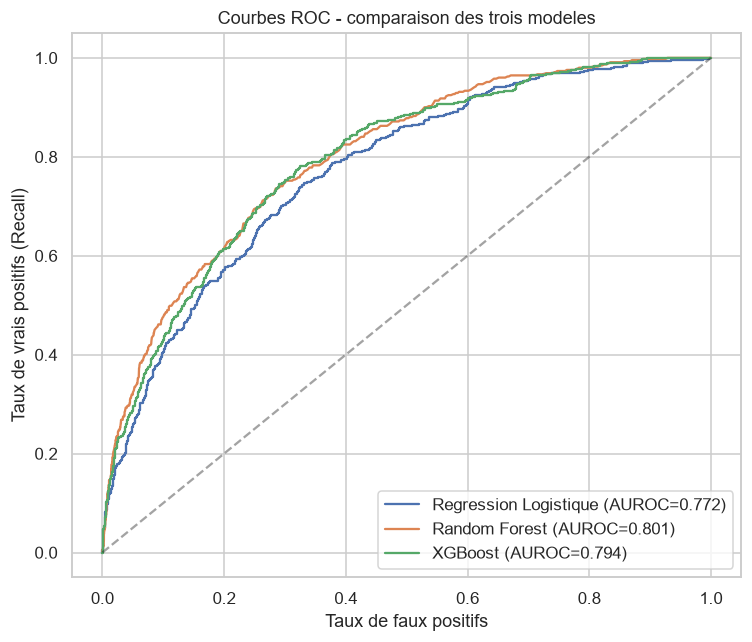

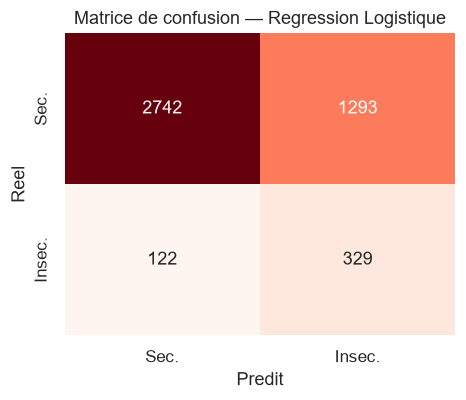

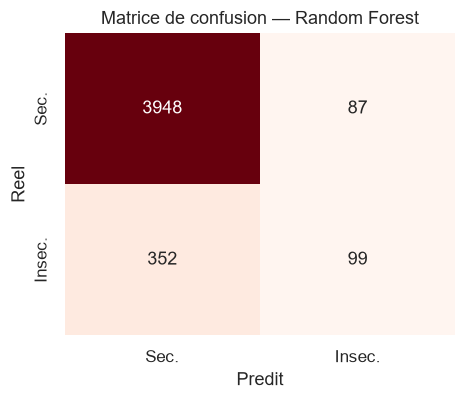

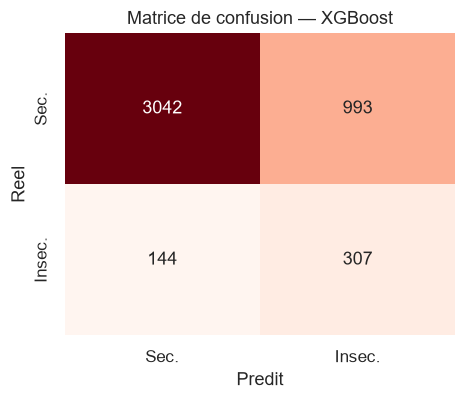

In [47]:
# Courbes ROC comparees
fig, ax = plt.subplots(figsize=(7, 6))
for name, p in models.items():
    fpr, tpr, _ = roc_curve(y_te, p)
    ax.plot(fpr, tpr, label=f"{name} (AUROC={roc_auc_score(y_te, p):.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("Taux de faux positifs"); ax.set_ylabel("Taux de vrais positifs (Recall)")
ax.set_title("Courbes ROC - comparaison des trois modeles"); ax.legend(loc="lower right")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/courbes_roc.png", bbox_inches="tight"); plt.show()

# Matrices de confusion — une figure par modèle (§4.8.1)
for name, p in models.items():
    cm = confusion_matrix(y_te, (p >= 0.5).astype(int))
    fig, ax = plt.subplots(figsize=(4.4, 3.8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", ax=ax, cbar=False,
                xticklabels=["Sec.", "Insec."], yticklabels=["Sec.", "Insec."])
    ax.set_title(f"Matrice de confusion — {name}")
    ax.set_xlabel("Predit"); ax.set_ylabel("Reel")
    slug = name.lower().replace(" ", "_")
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/matrice_confusion_{slug}.png", bbox_inches="tight")
    plt.show()

## 12. Calibration des probabilités prédites

Courbes de calibration + **test de Hosmer-Lemeshow** pour les trois modèles.
Recalibration **isotonique** du meilleur modèle si nécessaire.

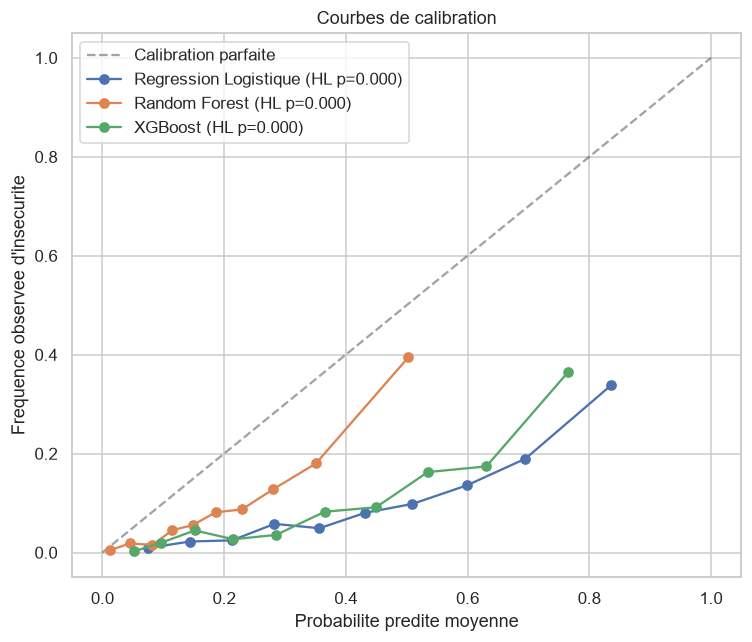

Test de Hosmer-Lemeshow (p>0.05 = bien calibre) :
  Regression Logistique    : HL=2755.85  p=0.0000  (mal calibre)
  Random Forest            : HL=302.09  p=0.0000  (mal calibre)
  XGBoost                  : HL=1763.38  p=0.0000  (mal calibre)


In [48]:
def hosmer_lemeshow(y_true, y_prob, g=10):
    dfh = pd.DataFrame({"y": y_true, "p": y_prob})
    dfh["decile"] = pd.qcut(dfh["p"], g, duplicates="drop")
    obs = dfh.groupby("decile", observed=True)["y"].sum()
    exp = dfh.groupby("decile", observed=True)["p"].sum()
    n   = dfh.groupby("decile", observed=True)["y"].count()
    hl = (((obs - exp) ** 2) / (exp * (1 - exp / n))).sum()
    dof = len(obs) - 2
    pval = 1 - stats.chi2.cdf(hl, dof)
    return hl, pval

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Calibration parfaite")
for name, p in models.items():
    frac_pos, mean_pred = calibration_curve(y_te, p, n_bins=10, strategy="quantile")
    hl, php = hosmer_lemeshow(y_te, p)
    ax.plot(mean_pred, frac_pos, "o-", label=f"{name} (HL p={php:.3f})")
ax.set_xlabel("Probabilite predite moyenne"); ax.set_ylabel("Frequence observee d'insecurite")
ax.set_title("Courbes de calibration"); ax.legend(loc="upper left")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/calibration.png", bbox_inches="tight"); plt.show()

print("Test de Hosmer-Lemeshow (p>0.05 = bien calibre) :")
for name, p in models.items():
    hl, php = hosmer_lemeshow(y_te, p)
    print(f"  {name:24} : HL={hl:6.2f}  p={php:.4f}  {'(bien calibre)' if php>0.05 else '(mal calibre)'}")

In [49]:
# Sélection du meilleur modèle selon les critères du mémoire (§4.8.3) :
#  - critère PRIMAIRE  : AUROC maximale sur l'échantillon test ;
#  - critère SECONDAIRE : si la différence d'AUROC entre les deux premiers n'est pas
#    significative (test de DeLong, alpha=5 %), retenir celui au Recall le plus élevé
#    (coût social asymétrique du faux négatif dans le contexte humanitaire).
comp_sorted = comp.sort_values("AUROC", ascending=False)
first, second = comp_sorted.index[0], comp_sorted.index[1]
_, _, _, p_top2 = delong_test(y_te.astype(float), models[first], models[second])
print(f"Critère primaire : {first} (AUROC={comp.loc[first,'AUROC']:.4f}) "
      f"devant {second} (AUROC={comp.loc[second,'AUROC']:.4f})")
print(f"Test de DeLong {first} vs {second} : p={p_top2:.4f}")
if p_top2 >= 0.05 and comp.loc[second, "Recall"] > comp.loc[first, "Recall"]:
    best_name = second
    print(f"AUROC statistiquement équivalentes -> critère secondaire (Recall) : "
          f"{second} ({comp.loc[second,'Recall']:.3f}) > {first} ({comp.loc[first,'Recall']:.3f})")
else:
    best_name = first
best_model = {"Regression Logistique": logit_pipe, "Random Forest": rf, "XGBoost": xgbm}[best_name]
print(f"### Meilleur modele retenu (§4.8.3) : {best_name}")

# Recalibration isotonique du modèle déjà entraîné (utile surtout pour Random Forest).
# sklearn >= 1.6 : on gèle le modèle avec FrozenEstimator au lieu de cv="prefit".
Xc, Xh, yc, yh = train_test_split(X_te, y_te, test_size=0.5, stratify=y_te, random_state=RANDOM_STATE)
try:
    try:
        from sklearn.frozen import FrozenEstimator
        calibrated = CalibratedClassifierCV(FrozenEstimator(best_model), method="isotonic")
    except Exception:
        calibrated = CalibratedClassifierCV(best_model, method="isotonic", cv="prefit")
    calibrated.fit(Xc, yc)
    p_cal = calibrated.predict_proba(Xh)[:, 1]
    p_raw = best_model.predict_proba(Xh)[:, 1]
    hl_raw, php_raw = hosmer_lemeshow(yh, p_raw)
    hl_cal, php_cal = hosmer_lemeshow(yh, p_cal)
    print(f"Brier avant recalibration : {brier_score_loss(yh, p_raw):.4f}  (HL p={php_raw:.3f})")
    print(f"Brier apres recalibration : {brier_score_loss(yh, p_cal):.4f}  (HL p={php_cal:.3f})")
    FINAL_MODEL = calibrated
except Exception as e:
    print("Recalibration ignoree :", e)
    FINAL_MODEL = best_model

Critère primaire : Random Forest (AUROC=0.8011) devant XGBoost (AUROC=0.7939)
Test de DeLong Random Forest vs XGBoost : p=0.0980
AUROC statistiquement équivalentes -> critère secondaire (Recall) : XGBoost (0.681) > Random Forest (0.220)
### Meilleur modele retenu (§4.8.3) : XGBoost
Brier avant recalibration : 0.1593  (HL p=0.000)
Brier apres recalibration : 0.0767  (HL p=0.479)


## 13. Interprétabilité — valeurs SHAP (§4.7)

SHAP calculé pour **les trois modèles** (§4.7.1) : **TreeSHAP** pour Random Forest et
XGBoost, **LinearSHAP** pour la Régression Logistique. Les **quatre visualisations** du
§4.7.2 sont produites, chaque graphique dans sa **propre figure** :
*summary plot* (importance globale + direction des effets), *dependence plots* (top 3
variables), *waterfall plots* (3 ménages représentatifs), *force plot* (HTML interactif
pour l'outil web, OS4).

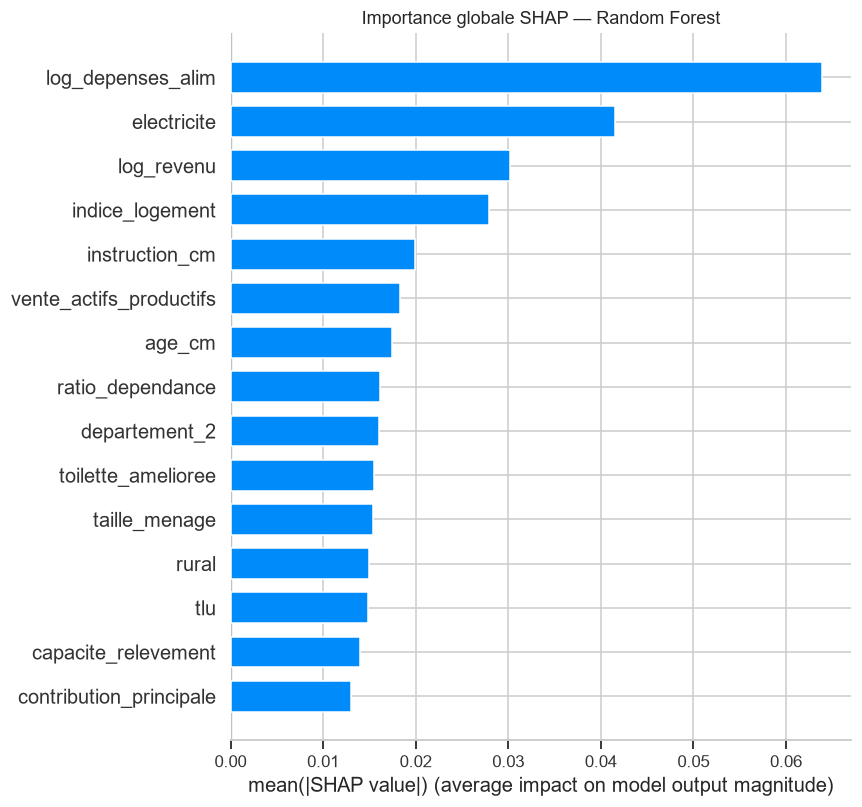

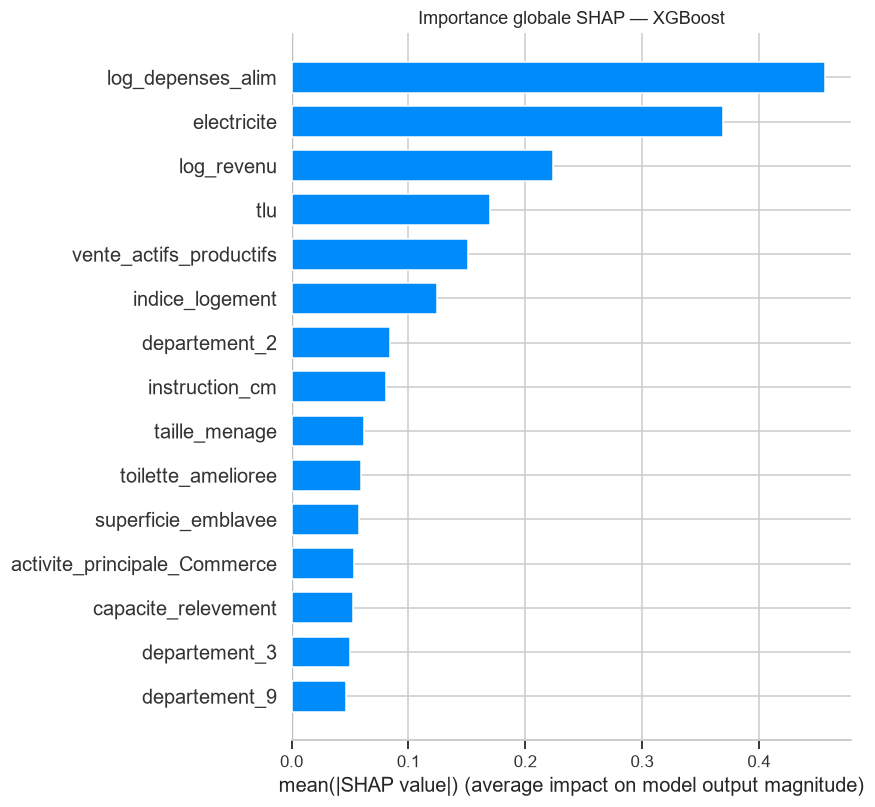

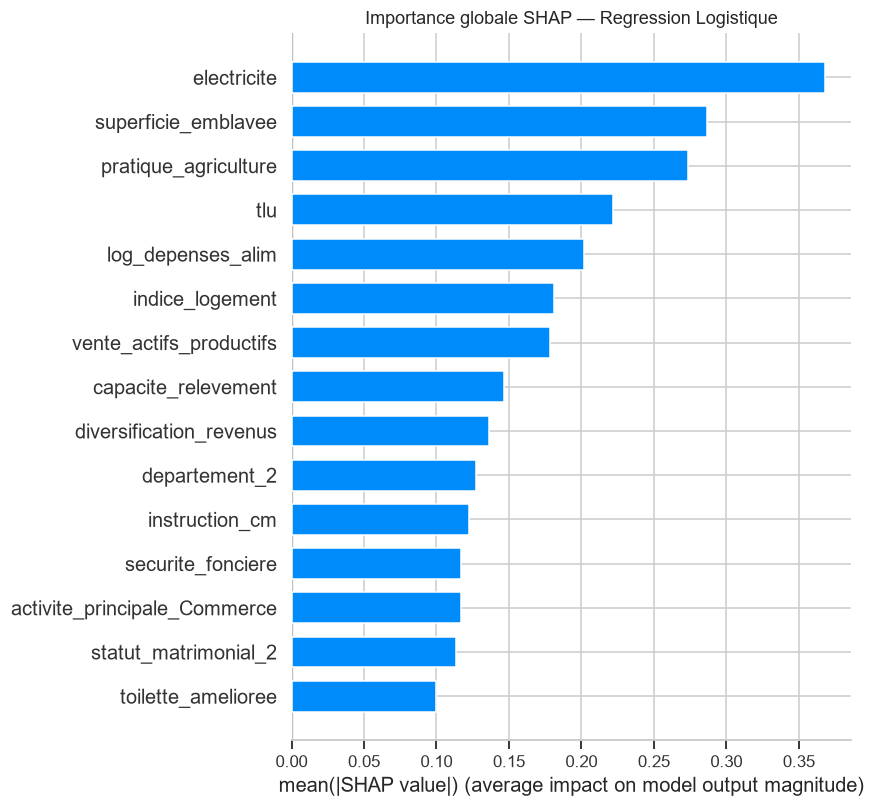

In [50]:
import shap

n_shap = 800 if FAST_MODE else 1200   # TreeSHAP exact O(TLD²) : suffisant pour des importances stables
samp = X_te.sample(min(n_shap, len(X_te)), random_state=RANDOM_STATE)

def _shap_positive(sv):
    """Extrait la matrice SHAP de la classe positive quelle que soit la forme retournée."""
    if isinstance(sv, list):          # RF (ancien format) -> liste par classe
        sv = sv[1]
    if hasattr(sv, "ndim") and sv.ndim == 3:
        sv = sv[:, :, 1]
    return sv

SHAP_VALUES, SHAP_DATA = {}, {}

# TreeSHAP — Random Forest & XGBoost (§4.7.1)
for name_m, mdl in [("Random Forest", rf), ("XGBoost", xgbm)]:
    try:
        SHAP_VALUES[name_m] = _shap_positive(shap.TreeExplainer(mdl).shap_values(samp))
        SHAP_DATA[name_m] = samp
    except Exception as e:
        print(f"TreeSHAP {name_m} :", e)

# LinearSHAP — Régression Logistique (sur variables standardisées, §4.7.1)
try:
    _scaler = logit_pipe.named_steps["scaler"]
    _clf    = logit_pipe.named_steps["clf"]
    samp_std = pd.DataFrame(_scaler.transform(samp), columns=samp.columns, index=samp.index)
    _bg = shap.sample(_scaler.transform(X_tr), 200, random_state=RANDOM_STATE)
    SHAP_VALUES["Regression Logistique"] = _shap_positive(
        shap.LinearExplainer(_clf, _bg).shap_values(samp_std))
    SHAP_DATA["Regression Logistique"] = samp_std
except Exception as e:
    print("LinearSHAP Logit :", e)

# Importance globale (moyenne des |SHAP|) — une figure par modèle
for name_m, sv in SHAP_VALUES.items():
    plt.figure()
    shap.summary_plot(sv, SHAP_DATA[name_m], plot_type="bar", show=False, max_display=15)
    plt.title(f"Importance globale SHAP — {name_m}")
    slug = name_m.lower().replace(" ", "_")
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/shap_importance_{slug}.png", bbox_inches="tight")
    plt.show()

### Summary plot (direction des effets) & dependence plots — meilleur modèle à arbres

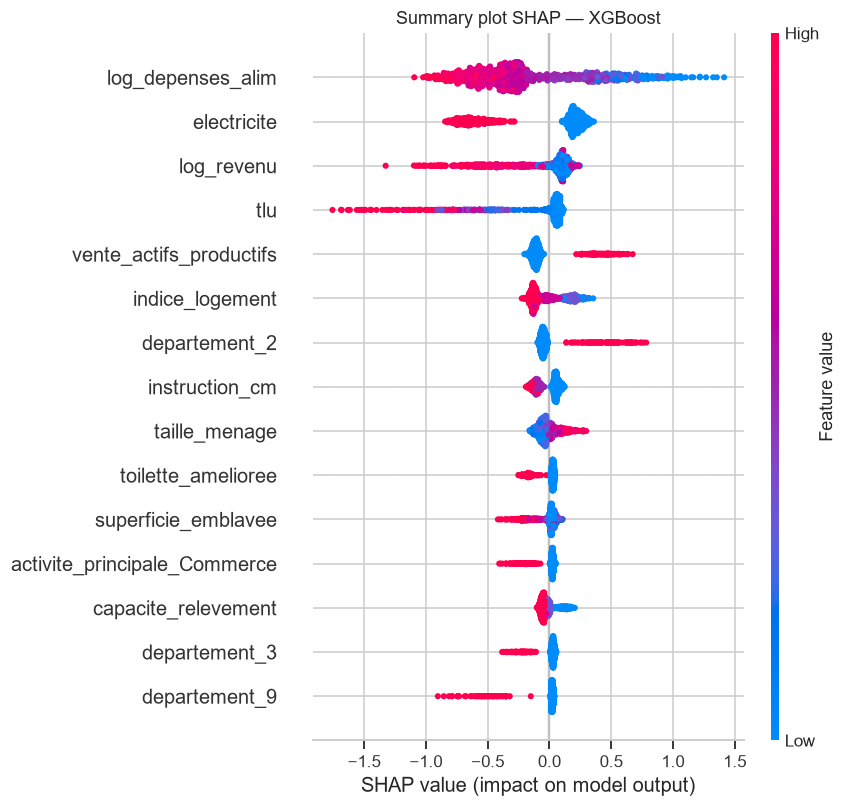

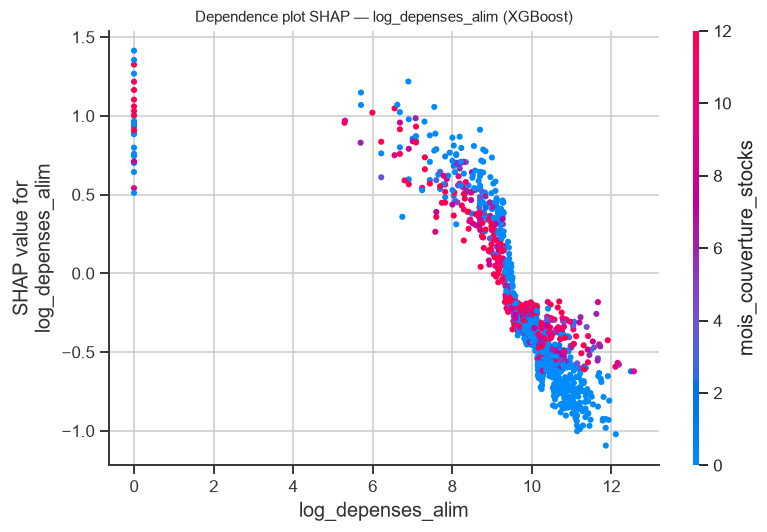

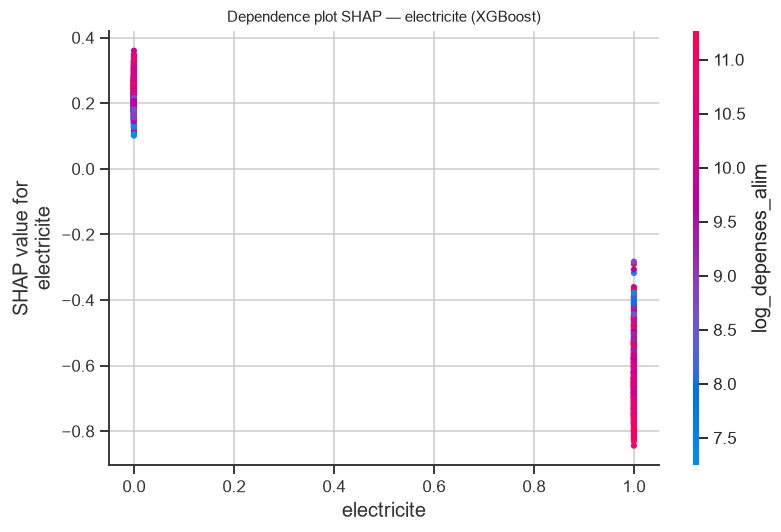

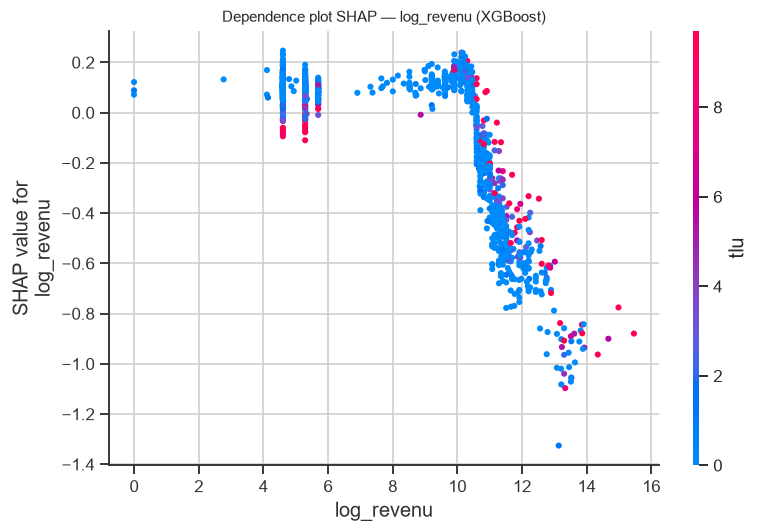

In [51]:
tree_name  = best_name if best_name in ("Random Forest", "XGBoost") else "XGBoost"
tree_model = {"Random Forest": rf, "XGBoost": xgbm}[tree_name]
sv_best = SHAP_VALUES.get(tree_name)

if sv_best is not None:
    # Summary plot (beeswarm) : rouge = augmente le risque, bleu = le réduit (§4.7.2)
    plt.figure()
    shap.summary_plot(sv_best, samp, show=False, max_display=15)
    plt.title(f"Summary plot SHAP — {tree_name}")
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/shap_summary.png", bbox_inches="tight"); plt.show()

    # Dependence plots : top 3 variables par importance moyenne |SHAP| — une figure chacune
    imp = pd.Series(np.abs(sv_best).mean(axis=0), index=samp.columns).sort_values(ascending=False)
    for var in imp.index[:3]:
        shap.dependence_plot(var, sv_best, samp, show=False)
        plt.title(f"Dependence plot SHAP — {var} ({tree_name})", fontsize=10)
        plt.tight_layout()
        plt.savefig(f"{OUT_DIR}/shap_dependence_{var}.png", bbox_inches="tight")
        plt.show()

### Waterfall plots (3 ménages représentatifs) & force plot (outil web, OS4)

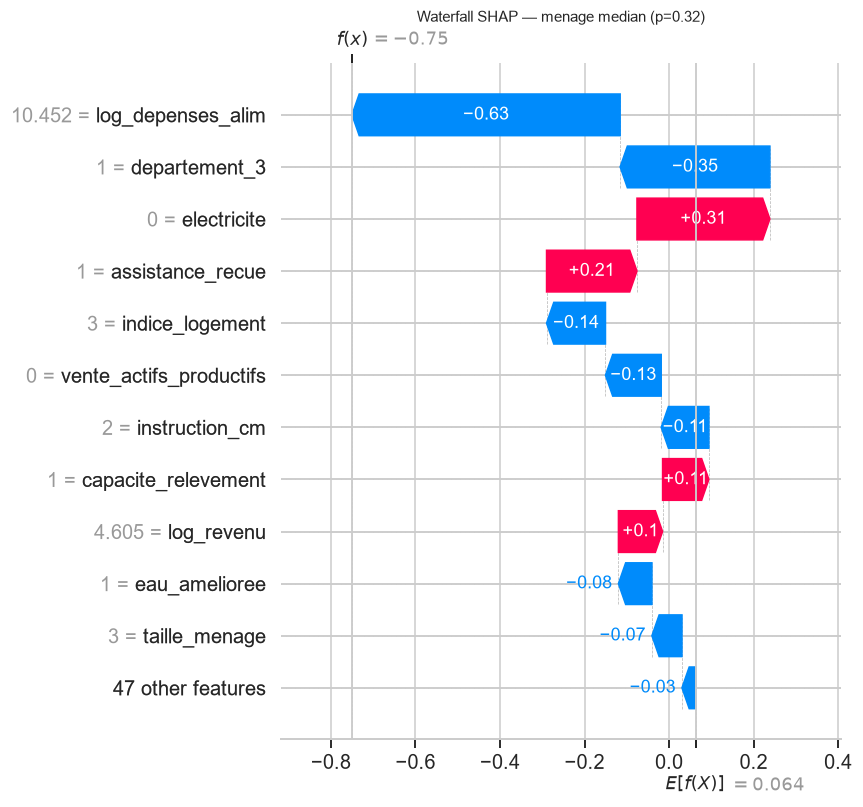

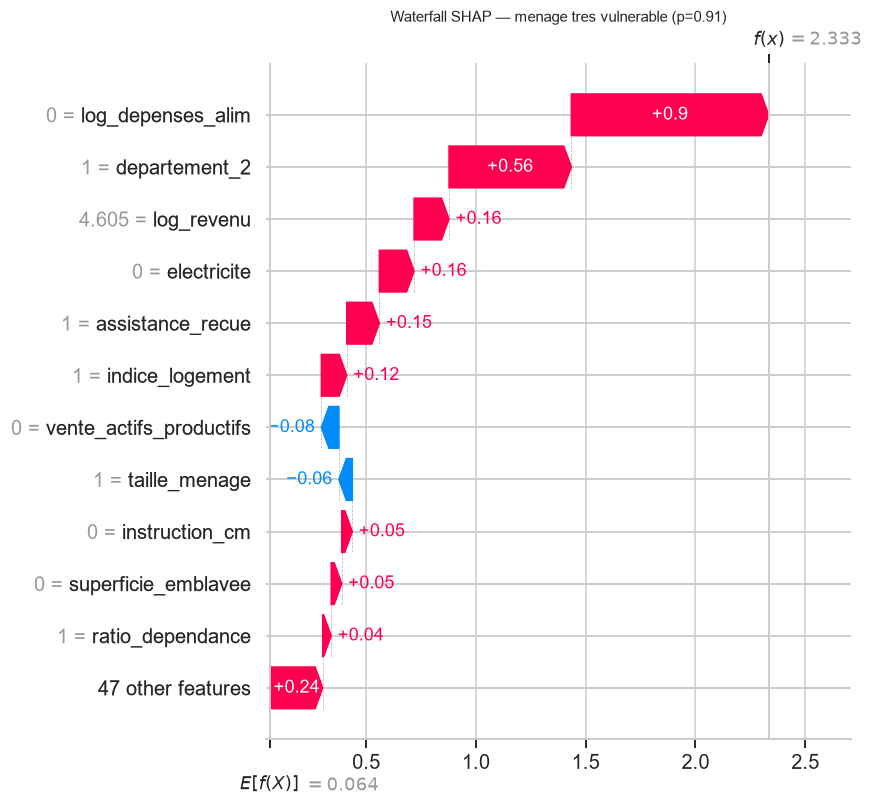

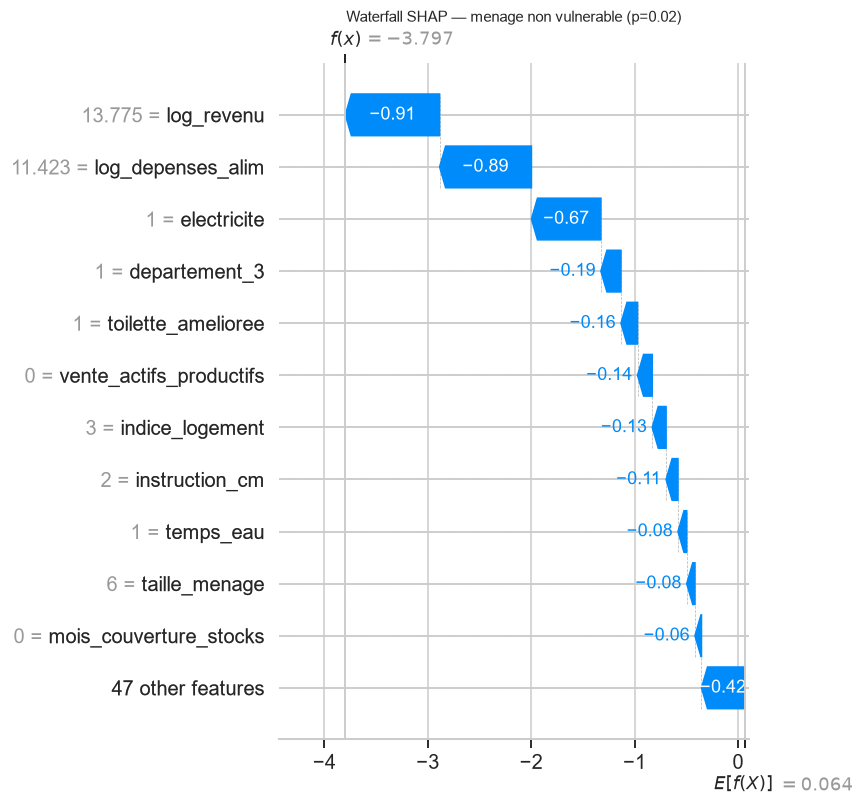

Force plot interactif : outputs/shap_force_menage_median.html


In [52]:
try:
    _expl = shap.TreeExplainer(tree_model)(samp, check_additivity=False)
    if _expl.values.ndim == 3:
        _expl = _expl[..., 1]
    proba_samp = tree_model.predict_proba(samp)[:, 1]
    menages_ref = {
        "menage_median":          int(np.argsort(proba_samp)[len(proba_samp) // 2]),
        "menage_tres_vulnerable": int(np.argmax(proba_samp)),
        "menage_non_vulnerable":  int(np.argmin(proba_samp)),
    }
    for lab, ix in menages_ref.items():
        plt.figure()
        shap.plots.waterfall(_expl[ix], max_display=12, show=False)
        plt.title(f"Waterfall SHAP — {lab.replace('_', ' ')} (p={proba_samp[ix]:.2f})",
                  fontsize=10)
        plt.tight_layout()
        plt.savefig(f"{OUT_DIR}/shap_waterfall_{lab}.png", bbox_inches="tight")
        plt.show()

    # Force plot interactif (HTML) du ménage médian — intégrable dans l'application web
    ixm = menages_ref["menage_median"]
    fp = shap.force_plot(float(np.ravel(_expl.base_values)[ixm]),
                         _expl.values[ixm], samp.iloc[ixm])
    shap.save_html(f"{OUT_DIR}/shap_force_menage_median.html", fp)
    print("Force plot interactif : outputs/shap_force_menage_median.html")
except Exception as e:
    print("Waterfall/force plots :", e)

## 14. Cartographie prédictive du risque à l'échelle communale

1. Probabilités individuelles prédites sur la base complète (meilleur modèle)
2. Agrégation **pondérée** par commune (poids d'enquête)
3. Jointure au fond de carte des communes (geoBoundaries ADM2)
4. **Indice de Moran** (autocorrélation spatiale)
5. Discrétisation **Jenks** + carte choroplèthe

In [53]:
# Probabilites predites sur toute la base
proba_all = FINAL_MODEL.predict_proba(X_all)[:, 1]
D_map = D.copy()
D_map["proba"] = proba_all

# Agregation ponderee par commune
def wavg(sub):
    return np.average(sub["proba"], weights=sub["weight"])
communes = (D_map.groupby("commune")
            .apply(lambda s: pd.Series({"proba_moy": wavg(s), "n": len(s)}), include_groups=False)
            .reset_index())

com_labels = {k: fix_moji(v) for k, v in VALUE_LABELS["commune"].items()}
communes["nom_commune"] = communes["commune"].map(com_labels)
print("Communes agregees :", communes.shape[0])
print(communes.sort_values("proba_moy", ascending=False).head(10).to_string(index=False))
communes.to_csv(f"{OUT_DIR}/risque_communal.csv", index=False)

Communes agregees : 77
 commune  proba_moy     n  nom_commune
      21   0.392657 137.0    Boukoumbé
      29   0.392506  60.0 Toucountouna
      28   0.230642 120.0    Tanguiéta
      22   0.225223 120.0        Cobly
      25   0.214614 180.0       Matéri
     122   0.192452 120.0 Agbangnizoun
      65   0.188651 180.0         Lalo
      26   0.187776 160.0   Natitingou
      66   0.177934 140.0     Toviklin
      62   0.174499 200.0   Djakotomey


In [54]:
import geopandas as gpd
gdf = gpd.read_file(GEO_FILE)

# Jointure par nom normalise (+ overrides pour les 6 variantes orthographiques)
overrides = {"akpro misserete": "akpo misserete", "boukoumbe": "boukombe",
             "cobly": "kobli", "dogbo tota": "dogbo",
             "pehonko": "pehunco", "zangnanado": "zagnanado"}
communes["key"] = communes["nom_commune"].map(lambda s: overrides.get(norm_name(s), norm_name(s)))
gdf["key"] = gdf["shapeName"].map(norm_name)

geo = gdf.merge(communes, on="key", how="left")
print("Communes appariees au fond de carte :", int(geo["proba_moy"].notna().sum()), "/", len(geo))

Communes appariees au fond de carte : 77 / 77


In [55]:
# Indice de Moran (autocorrelation spatiale)
from libpysal.weights import Queen
from esda.moran import Moran

geo_valid = geo[geo["proba_moy"].notna()].copy().reset_index(drop=True)
W = Queen.from_dataframe(geo_valid, use_index=False)
W.transform = "r"
moran = Moran(geo_valid["proba_moy"].values, W)
print(f"Indice de Moran I = {moran.I:.4f}  |  p-value = {moran.p_sim:.4f}")
print("=> Autocorrelation spatiale positive significative (H3 confirmee)."
      if (moran.I > 0 and moran.p_sim < 0.05)
      else "=> Pas d'autocorrelation spatiale significative detectee.")

Indice de Moran I = 0.5697  |  p-value = 0.0010
=> Autocorrelation spatiale positive significative (H3 confirmee).


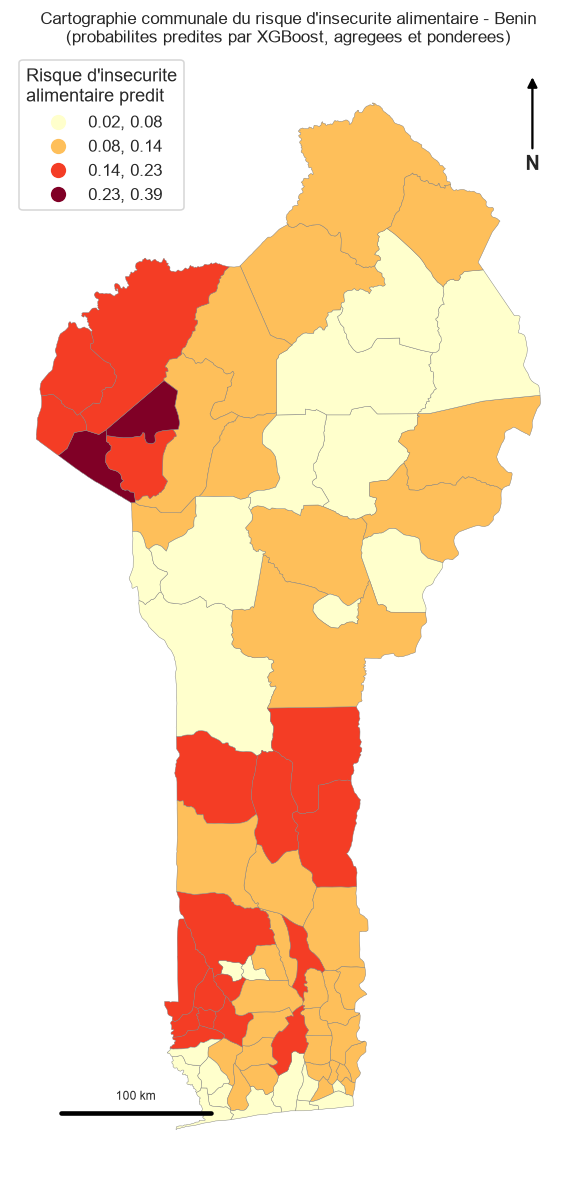

Carte enregistree : outputs/carte_risque_communal.png


In [56]:
# Carte choroplethe (discretisation Jenks - seuils naturels)
fig, ax = plt.subplots(figsize=(9, 11))
geo.plot(column="proba_moy", scheme="NaturalBreaks", k=4, cmap="YlOrRd",
         legend=True, edgecolor="grey", linewidth=0.3, ax=ax,
         missing_kwds={"color": "lightgrey", "label": "Non enquete"},
         legend_kwds={"title": "Risque d'insecurite\nalimentaire predit"})
ax.set_title("Cartographie communale du risque d'insecurite alimentaire - Benin\n"
             f"(probabilites predites par {best_name}, agregees et ponderees)", fontsize=11)
ax.axis("off")

# Standards cartographiques (§4.9.4) : flèche Nord + échelle graphique
ax.annotate("N", xy=(0.94, 0.98), xytext=(0.94, 0.90), xycoords="axes fraction",
            arrowprops=dict(arrowstyle="-|>", color="black", lw=1.5),
            ha="center", va="center", fontsize=13, fontweight="bold")
_x0, _y0 = geo.total_bounds[0] + 0.15, geo.total_bounds[1] + 0.10
_deg100 = 100 / 109.4   # 1° de longitude ≈ 109,4 km à ~9,3° N (latitude moyenne du Bénin)
ax.plot([_x0, _x0 + _deg100], [_y0, _y0], color="black", lw=3)
ax.text(_x0 + _deg100 / 2, _y0 + 0.08, "100 km", ha="center", fontsize=8)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/carte_risque_communal.png", dpi=150, bbox_inches="tight")
plt.show()
print("Carte enregistree : outputs/carte_risque_communal.png")

In [57]:
# Carte interactive (folium) pour l'outil web (OS4)
import folium
geo_wgs = geo.to_crs(4326)
centroid = geo_wgs.geometry.union_all().centroid
m = folium.Map(location=[centroid.y, centroid.x], zoom_start=7, tiles="CartoDB positron")
folium.Choropleth(
    geo_data=geo_wgs.__geo_interface__,
    data=communes, columns=["key", "proba_moy"],
    key_on="feature.properties.key",
    fill_color="YlOrRd", fill_opacity=0.75, line_opacity=0.3,
    nan_fill_color="lightgrey",
    legend_name="Probabilite predite d'insecurite alimentaire",
).add_to(m)
for _, r in geo_wgs.iterrows():
    if pd.notna(r["proba_moy"]):
        folium.GeoJson(
            r["geometry"].__geo_interface__,
            tooltip=f"{r['shapeName']} : {r['proba_moy']*100:.1f} %",
            style_function=lambda _feat: {"fillOpacity": 0, "weight": 0},
        ).add_to(m)
m.save(f"{OUT_DIR}/carte_interactive.html")
print("Carte interactive enregistree : outputs/carte_interactive.html")

Carte interactive enregistree : outputs/carte_interactive.html


## 15. Reproductibilité logicielle (§4.10.1)

Versions exactes des packages (équivalent `requirements.txt`) + graine aléatoire unique
`RANDOM_STATE = 42` propagée à toutes les étapes stochastiques du pipeline.

In [58]:
import sys
import importlib.metadata as ilm

pkgs = ["pandas", "numpy", "scipy", "statsmodels", "scikit-learn", "xgboost", "shap",
        "imbalanced-learn", "samplics", "geopandas", "libpysal", "esda", "mapclassify",
        "folium", "seaborn", "matplotlib", "pyreadstat", "jupytext"]
ver_lines = [f"# Python {sys.version.split()[0]}"]
for pkg in pkgs:
    try:
        ver_lines.append(f"{pkg}=={ilm.version(pkg)}")
    except ilm.PackageNotFoundError:
        ver_lines.append(f"# {pkg} : non installe")
print("\n".join(ver_lines))
with open(f"{OUT_DIR}/requirements_versions.txt", "w", encoding="utf-8") as fh:
    fh.write("\n".join(ver_lines) + "\n")
print(f"\nRANDOM_STATE = {RANDOM_STATE} propage a toutes les etapes stochastiques.")
print("Versions enregistrees : outputs/requirements_versions.txt")

# Python 3.11.3
pandas==3.0.3
numpy==2.4.6
scipy==1.17.1
statsmodels==0.14.6
scikit-learn==1.9.0
xgboost==3.2.0
shap==0.51.0
imbalanced-learn==0.14.2
samplics==0.6.0
geopandas==1.1.4
libpysal==4.14.1
esda==2.9.0
mapclassify==2.10.0
folium==0.20.0
seaborn==0.13.2
matplotlib==3.11.1
pyreadstat==1.3.5
jupytext==1.19.5

RANDOM_STATE = 42 propage a toutes les etapes stochastiques.
Versions enregistrees : outputs/requirements_versions.txt


## Synthèse

Le pipeline complet a produit dans `outputs/` :
- `donnees_analytiques.csv` — échantillon nettoyé (variables des 5 capitaux + Y)
- `univarie_*.csv` / `univarie_*.png` — analyse univariée des six variables focales (§4.4.2)
- `normalite_tests.csv`, `normalite_qqplots.png` — tests de normalité (§4.4.3)
- `bivarie_focales.csv`, `bivarie_*.png` — analyse bivariée focale (§4.4.4)
- `tests_bivaries.csv` — synthèse des tests χ²/Mann-Whitney corrigés FDR
- `odds_ratios_logit.csv` — déterminants (OS1)
- `comparaison_modeles.csv` — AUROC/Accuracy/Recall/F1/Brier des 3 modèles (OS2)
- `pseudo_r2.csv` — pseudo-R² McFadden/Cox-Snell/Nagelkerke (qualité d'ajustement, §4.5.3)
- `matrice_confusion_*.png` — matrices de confusion, une par modèle
- `shap_importance_*.png`, `shap_summary.png`, `shap_dependence_*.png`,
  `shap_waterfall_*.png`, `shap_force_menage_median.html` — les 4 visualisations SHAP (§4.7.2)
- `requirements_versions.txt` — versions des packages (§4.10.1)
- `risque_communal.csv`, `carte_risque_communal.png`, `carte_interactive.html` — cartographie (OS3/OS4)

Passez `FAST_MODE = False` (cellule 0) pour exécuter les grilles d'hyperparamètres
complètes et la validation croisée à 10 plis du mémoire.